# ATLANTID: a robust dolphin whistle classifier for the Southwestern Atlantic Ocean — Master Notebook



**Authors**: Rafael G. de Menezes & Alexandre Paro  #Esta primeira célula de markdown eu editei, mas não hora de rodar deu um erro de sintaxe
**Reference:** Paro et al., 2025 (in preparation)

---

### 🎯 Objective
Development of a ** whistle classification system for dolphin species** using PAMGuard ROCCA Countour Stats csv sheets

A whistle is an individual sample 
An acoustic event is defined as a set of whistles collected from a dolphin encounter
The acoustic event ID refers to the EncounterNumber in the ROCCA Countour Stats sheet
    
This notebook integrates multiple training and evaluation strategies:

- **K-FOLD**: cross-validation for classifying individual whistles spliting the data in 5 folds 
- **LOGO-IND**: Leave-One-Group-Out cross-validation by individual whistles  (groups refers to acoustic events) 
- **LOGO-EVENT**: Leave-One-Group-Out cross-validation by acoustic events 
- **META-CLASSFIER**: uses the probabilities generated by the by K-FOLD, LOGO-IND and LOGO-EVENT as inputs for a meta-classifier
- **New Data Prediction**: applying trained models to unseen acoustic events  

---

### 📦 Outputs
The workflow generates reproducible and shareable artifacts:

- **Feature tables** (processed and standardized)  
- **Trained model(s)** ready for reuse  
- **Evaluation materials**: plots, metrics, and summary reports  


## Importing libraries and setting variables

In [1]:
## Main configurations
exp_name     = 'testing'
master_file  = 'Master_Whistle_7sp.csv'
predict_only = False #True # Set to True to skip training and only do predictions on new data

In [2]:
sep = '=' * 50
print(f"{sep}\nCetacea Whistle Classifier — Master Notebook\nStarting code, imports, and global variables")
import os, joblib, platform, warnings
from typing import Iterable, Tuple, List, Dict, Any, Optional
from pathlib import Path
# from itertools import chain
import numpy as np
import pandas as pd
import sklearn
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import balanced_accuracy_score, classification_report, confusion_matrix, accuracy_score
# from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt
import seaborn as sns
# import ipywidgets as W
# from IPython.display import display
print("\tPython:", platform.python_version())
print("\tNumPy:", np.__version__)
print("\tPandas:", pd.__version__)
print("\tScikit-learn:", sklearn.__version__)
print("\tSeaborn:", sns.__version__)

pd.set_option('display.max_rows', None )
pd.set_option('display.max_columns', None )
pd.set_option('display.width', 100)
print(sep)
plt.rcParams["figure.figsize"] = (5, 4)
plt.rcParams["axes.grid"] = False

BASE_DIR = Path.cwd()
DATA_DIR = os.path.join(BASE_DIR, "inputs")
OUT_DIR  =  os.path.join(BASE_DIR, "outputs")


# --- GENERAL FUNCTIONS ---
def read_ROCCA_sheet(filepath, type = 'original'):
    df = pd.read_csv(filepath)
    if type != 'original':
        df = df.drop(['Source', 'EncounterID', 'CruiseID'], axis=1)
    else:
        col_exclude = (list(df.loc[:, 'Source':'EncounterCount'].columns) +
                        list(df.loc[:, 'SamplingRate':'DataProvider'].columns) + 
                        ['GeographicLocation','ClassifiedSpecies', 'DCMEAN', 'DCSTDDEV'] +
                        list(df.loc[:, 'DCQUARTER1MEAN':'DCQUARTER4MEAN'].columns) +
                        list(df.loc[:, 'FREQBEGSWEEP':'FREQENDDWN'].columns) +
                        list(df.loc[:, 'FREQPEAK':'Species_List'].columns))
        df = df.drop(columns = col_exclude)
    return df

def get_preset_configs (PRESETS, PATH, preset_label, grouping_type='LOGO', oob_score=False, min_samples_leaf=1, min_samples_split=2):
    if preset_label not in PRESETS["preset_labels"]:
        raise ValueError(f"Preset label {preset_label!r} not found in PRESETS['preset_labels'].")
    i = PRESETS['preset_labels'].index(preset_label)
    configs = {k: v[i] for k, v in PRESETS.items() if k != "preset_labels"} # Build a dict with the i-th value for each key

    configs['n_jobs'] = -1 # Use all available CPU cores
    configs['oob_score'] = oob_score        
    if 'logo' in grouping_type.lower(): configs['oob_score'] = True  # Force OOB for LOGO
    configs['min_samples_leaf']  = min_samples_leaf   
    configs['min_samples_split'] = min_samples_split                   
    
    cfgfile_path = os.path.join(PATH, f'{preset_label}_{grouping_type}_configs.txt')
    with open(cfgfile_path, 'w') as f:
        print("Configuration:")
        for key, value in configs.items():
            f.write(f"{key}: {value}\n")
            print(f"\t{key:>12}: {value}")

    rfc_params = {k: v for k, v in configs.items() if not k.startswith("rs_")}
    return configs, rfc_params
    
def adjust_confusion_matrix(matrix): 
    # Function to round and adjust the confusion matrix percentages that sum up to 100% in each row
    matrix = matrix.astype('float') / matrix.sum(axis=1)[:, np.newaxis] # Compute the confusion matrix percentage
    rounded_matrix = np.floor(matrix * 100).astype(int)  # Round down to ensure totals <= 100
    row_sums = rounded_matrix.sum(axis=1)
    for i in range(len(row_sums)):
        errors = 100 - row_sums[i]  # Calculate how much we need to adjust
        if errors > 0:
            # Increment the highest decimal part entries
            decimal_part = (matrix[i] * 100) - np.floor(matrix[i] * 100)
            adjust_indices = np.argsort(decimal_part)[-errors:]  # Get indices with the highest decimals
            rounded_matrix[i, adjust_indices] += 1
    return rounded_matrix

def plot_confusion_matrix_heatmap(matrix, class_labels: List[str], preset: str, save_dir: str,
                                sorted: bool=False, grouping: str = "LOGO", show: bool = True, dpi: int = 300):  
    """ Plot and save a styled confusion matrix heatmap.
    Parameters
        matrix : np.ndarray ->             Confusion matrix (integer percentages, e.g. from adjust_confusion_matrix).
        class_labels : list of str ->       Labels for rows/columns. 
        preset : str ->                      Preset name (used in title and filename).
        save_dir : str ->                    Directory to save the figure.
        sorted : bool, default=True ->       If True, sort classes by diagonal values. 
        grouping : str, default="KFOLD" ->   Name to include in the title/filename.
        show : bool, default=False ->        If True, display with plt.show(); otherwise close after saving.
        dpi : int, default=300 ->           Resolution of saved PNG.
    Returns
        conf_figpath : str ->               Path where the figure was saved."""
    
    if sorted:    
        diagonal_values = np.diag(matrix)                           # Calculate diagonal values for sorting
        sorted_indices  = np.argsort(diagonal_values)[::-1]         # Get sorted indices based on diagonal values (highest to lowest)
        matrix          = matrix[sorted_indices][:, sorted_indices] # Create a new confusion matrix that reflects the sorted labels while preserving original percentages
        class_labels    = [class_labels[i] for i in sorted_indices] # Reorder the class labels according to the sorted diagonal values
        
    plt.figure()    
    plt.title(f"{grouping} Confusion Matrix - {preset}")
    heatmap = sns.heatmap(matrix / 100.0,  # normalize to [0,1] for colormap
                          annot=True,cmap="Greys", fmt="", xticklabels=class_labels, yticklabels=class_labels,
                          annot_kws={"size": 10},cbar_kws={"shrink": 0.8}, 
                          linewidths=0.0, linecolor="white",
                          square=True              # optional, makes cells clean and uniform
                        )
    # Style axes
    ax = plt.gca()

    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(0.3)
        
    # Style colorbar
    cbar = heatmap.collections[0].colorbar
    cbar.outline.set_edgecolor("black")
    cbar.outline.set_linewidth(0.2)
    # Axis labels
    plt.xlabel("Predicted Species", fontsize=12, fontweight="bold", labelpad=10)
    plt.ylabel("True Species", fontsize=12, fontweight="bold", labelpad=10)
    plt.xticks(rotation=45)
    # Save
    os.makedirs(save_dir, exist_ok=True)
    conf_figpath = os.path.join(save_dir, f"{preset}_{grouping}_Confusion_Matrix.png")
    print(f"\n[saving] Confusion Matrix {grouping} at {conf_figpath}")
    plt.savefig(conf_figpath, format="png", bbox_inches="tight", dpi=dpi)
    if show: plt.show()
    else:    plt.close()
    return conf_figpath

def average_presets_reports(
    tables: List[pd.DataFrame],
    presets_labels: List[str],
    out_dir: str,
    method_tag: str = "KFOLD",
    label_col: str = "Labels",
    save: bool = True
) -> pd.DataFrame:
    """
    Average classification reports across presets.
    
    Assumptions:
    - Each table contains rows for each class plus rows like:
          'accuracy', 'macro avg', 'weighted avg', 'balanced_accuracy'
    - The schema matches:
        Labels | precision | recall | f1-score | support
    - Non-applicable entries (e.g. NaN recall for balanced_accuracy) 
      remain NaN and are NOT averaged incorrectly.

    Returns the averaged report as a DataFrame.
    """

    if not tables:
        raise ValueError("No tables provided for report averaging.")

    print("\nAveraging classification reports...")

    # --- standardize input ---
    standardized = []
    for df in tables:
        df2 = df.copy()
        # Ensure numeric columns are float so mean works cleanly
        for col in ["precision", "recall", "f1-score", "support"]:
            if col in df2.columns:
                df2[col] = pd.to_numeric(df2[col], errors="coerce")
        standardized.append(df2)

    # --- concatenate all presets ---
    all_df = pd.concat(standardized, ignore_index=True)

    # group by Labels → average metrics
    numeric_cols = ["precision", "recall", "f1-score", "support"]

    avg_df = (
        all_df.groupby(label_col, as_index=False)[numeric_cols]
        .mean(numeric_only=True)
    )

    # reorder columns exactly like input
    out_cols = [label_col] + numeric_cols
    avg_df = avg_df[out_cols]

    # save if needed
    if save:
        os.makedirs(out_dir, exist_ok=True)
        presets_str = "".join(presets_labels)
        fname = f"_{presets_str}_{method_tag}_Averaged_Class_Report.csv"
        fpath = os.path.join(out_dir, fname)
        print(f"[saving] {fpath}")
        avg_df.to_csv(fpath, index=False)

    return avg_df


def average_presets_probs(tables: List[pd.DataFrame],presets_labels: List[str],
                        out_dir: str, method_tag: str = "KFOLD",
                        meta_cols: Tuple[str, ...] = ("Species_Classification", "UID", "EncounterNumber", "KnownSpecies"),
                        save: bool = True,) -> pd.DataFrame:
    """Average species probability columns across a list of DataFrames (one per preset).
    - Detects class-probability columns from the FIRST table as all columns
      before the first meta column in `meta_cols` (or all non-meta columns if
      no meta column is present).
    - Preserves class column order from the FIRST table.
    - Averages per UID if present; otherwise averages by row index.
    - Reattaches EncounterNumber & KnownSpecies from the first occurrence per UID/index.
    Returns the averaged DataFrame and optionally saves it as:
      _<concatenated preset labels>_<method_tag>_Averaged_Probs.csv"""
    if not tables: raise ValueError("No tables provided.")

    print('\nAveraging probabilities...')
    base = tables[0].copy()
    # Figure out class-prob columns (prefer “before first meta col” rule)
    cols = list(base.columns)
    stop_idx_candidates = [cols.index(c) for c in meta_cols if c in cols]
    if stop_idx_candidates:
        stop_idx = min(stop_idx_candidates)
        class_cols = cols[:stop_idx]
        # other_cols = cols[stop_idx:]
    else:
        class_cols = [c for c in cols if c not in meta_cols]
        # other_cols = [c for c in cols if c in meta_cols]
    if not class_cols:
        raise ValueError("No class-probability columns detected; check table layout/meta_cols.")

    # Concatenate all presets
    all_df = pd.concat(tables, ignore_index=True)
    # Average numeric class columns
    avg_probs = (all_df.groupby("UID", as_index=False)[class_cols].mean(numeric_only=True))
    # Take first EncounterNumber / KnownSpecies per UID
    meta_first = (all_df.groupby("UID", as_index=False)[[c for c in meta_cols if c != "UID"]].first())
    avg_probs = avg_probs.merge(meta_first, on="UID", how="left")
    # Reorder columns: class probs (in base order) + meta (UID, EncounterNumber, KnownSpecies in that order)
    meta_in_out = [c for c in meta_cols if c in avg_probs.columns]
    avg_probs = avg_probs[class_cols + meta_in_out]
    if save: # Save
        os.makedirs(out_dir, exist_ok=True)
        presets_str = "".join(presets_labels)
        fname = f"_{presets_str}_{method_tag}_Averaged_Probs.csv"
        fpath = os.path.join(out_dir, fname)
        print(f"[saving] {fpath}")
        avg_probs.to_csv(fpath, index=False)
    return avg_probs

# --- KFOLD FUNCTIONS ---
def balance_train_data_kfold(X, weights, target_class_size, RS_bal_1=42, RS_bal_2=43, RS_bal_3=44):
    all_sampled_data = pd.DataFrame()
    # Iterate over each class and their corresponding group weights
    for class_label, group_weights in weights.items():
        class_data = X[X['KnownSpecies'] == class_label]
        total_samples = 0
        group_samples = {}
        # First pass: Sample from groups according to their weights
        for group, weight in group_weights.items():
            group_data = class_data[class_data['EncounterNumber'] == group]
            n_samples = int(weight * target_class_size)  # Allocate samples based on group weight
            # Adjust n_samples if it exceeds available samples in the group
            n_samples = min(n_samples, len(group_data))
            total_samples += n_samples
            if n_samples > 0:
                group_samples[group] = group_data.sample(n=n_samples, replace=False, random_state= RS_bal_1)

        # Combine sampled groups for this class
        sampled_data    = pd.concat(group_samples.values())
        sampled_indices = sampled_data.index.tolist()  # Track sampled indices
        # If we don't have enough samples for this class, sample more from the remaining class data
        if len(sampled_data) < target_class_size:
            remaining_data = class_data[~class_data.index.isin(sampled_indices)]
            if not remaining_data.empty:
                # Calculate the number of additional samples needed
                additional_samples = target_class_size - len(sampled_data)
                if additional_samples > 0:
                    # Sample remaining data to fill the gap, ensuring we don't oversample any group
                    remaining_sampled_data = remaining_data.sample(n=additional_samples, replace=False, random_state= RS_bal_2)
                    sampled_data = pd.concat([sampled_data, remaining_sampled_data])
        # Ensure the final sample size matches the target_class_size
        if len(sampled_data) > target_class_size:
            sampled_data = sampled_data.sample(n=target_class_size, replace=False, random_state= RS_bal_3)
        # Accumulate the sampled data across all classes
        all_sampled_data = pd.concat([all_sampled_data, sampled_data])

    # Separate features and target for the final balanced dataset
    all_sampled_data = all_sampled_data.reset_index(drop=True)
    X_balanced = all_sampled_data.drop(columns=['KnownSpecies'])
    y_balanced = all_sampled_data['KnownSpecies'].reset_index(drop=True)
    return X_balanced, y_balanced

def predict_kfold_probs(new_data_clean, all_models_kfold):
    all_avg_probs = []

    for model_label, models in all_models_kfold.items():
        fold_probs = []

        for rf_model in models:
            X_new_input = new_data_clean.drop(columns=['EncounterNumber', 'KnownSpecies'], errors='ignore')
            probs = rf_model.predict_proba(X_new_input)
            probs_df = pd.DataFrame(probs, columns=rf_model.classes_, index=new_data_clean.index)
            fold_probs.append(probs_df)

        model_avg_probs = sum(fold_probs) / len(fold_probs)
        all_avg_probs.append(model_avg_probs)

    final_avg_probs_df_kfold = sum(all_avg_probs) / len(all_avg_probs)
    final_avg_probs_df_kfold.index = new_data_clean.index
    final_avg_probs_df_kfold.columns = [f'{col}_KFOLD_5' for col in final_avg_probs_df_kfold.columns]
    return final_avg_probs_df_kfold

# --- LOGO FUNCTIONS ---
def find_minimum(df: pd.DataFrame,factors: Iterable[str], print_details: bool = False) -> Tuple[int, pd.Index]:
    """Returns:
        nbal: minimum count per factor1
        factor1_list: ordered unique labels of factor1 (Index)"""
    factor       = list(factors) if isinstance(factors, (list, tuple)) else [factors]
    factor1      = factor[0]
    counts       = df.groupby(factor1, observed=True).size()
    nbal         = counts.min()
    keymin       = counts.idxmin()
    factor1_list = counts.index
    if print_details:
        print('='*25)
        print(f"Key of {factor1} with minimum entries -> {keymin}")
        if len(factor) >= 2:
            factor2 = factor[1]
            details = df.loc[df[factor1] == keymin].groupby(factor2, observed=True).size()
            print(details)
        print('='*25)
    return int(nbal), factor1_list

def weighted_subsampling(df2subsample: pd.DataFrame, factors: Iterable[str], nbal: int, factor_val: str, rng_seed: Optional[int] = None) -> pd.DataFrame:
    """Subsample nbal rows from df where factor1 == chosen value,
    weighting by inverse counts of factor2 to balance within factor1."""
    factor = list(factors)
    factor1, factor2 = factor[0], factor[1]
    filtered = df2subsample.loc[df2subsample[factor1] == factor_val]
    if filtered.empty: raise ValueError(f"No rows found for {factor1} == {factor_val!r}")
    # ---- weights = 1 / count_per_factor2 (normalized)
    counts_per_f2 = filtered.groupby(factor2, observed=True)[factor1].transform("count")
    weights = (1.0 / counts_per_f2).astype(float)
    weights /= weights.sum()
    return filtered.sample(n=nbal, weights=weights, random_state=rng_seed)

def build_balanced_training_set(data2balance: pd.DataFrame,factors: Iterable[str], sampler_seed: Optional[int] = None) -> pd.DataFrame:
    """For each label of factor1, sample 'nbal' rows (weighted across factor2)."""
    nbal, factor1_list = find_minimum(data2balance, factors, print_details=False)
    print(f"\t\t\t\t\t[nbal] = {nbal}")
    # factor1 = list(factors)[0]
    parts = []
    for ft in factor1_list:
        sub = weighted_subsampling(df2subsample=data2balance, factors=factors, nbal=nbal, factor_val=ft, rng_seed=sampler_seed)
        parts.append(sub)
    df_balanced = pd.concat(parts, axis=0, ignore_index=False)
    return df_balanced

def testing_loop(mastersheet:  pd.DataFrame,
                 RFC: RandomForestClassifier,
                 factors:      Iterable[str],                 # e.g., ("KnownSpecies","EncounterNumber") or similar
                #  rfc_params:    Dict[str, Any],              # e.g., {"n_estimators":..., "max_features":..., "max_depth":..., "random_state": RS_rf, "oob_score": True}
                 sampler_seed: Optional[int] = None,     # seed used in subsampling
                 sep = '='*50
                ) -> Dict[str, Any]:
    """For each factor1 label:
            For each factor2 label under that factor1:
                - Train on all data EXCEPT rows with that factor2 label
                - Balance by factor1 using subsampling
                - Fit RandomForest
                - Predict on the held-out (factor1==label, factor2==held-out)
            Returns nested dict with predictions, probabilities, votes, etc."""
    factor1, factor2 = list(factors)[:2]
    factor1_list = mastersheet[factor1].drop_duplicates().reset_index(drop=True)
    results: Dict[str, Any] = {}
    fitted_models = {}
    # RFC = RandomForestClassifier(**rfc_params)
    print(f"\n{sep}\nIteration for each {factor1}:")
    for ft1 in factor1_list:
        print(f"\n\t\t{ft1}:")
        df_ft1 = mastersheet.loc[mastersheet[factor1] == ft1]
        ft2_ft1 = df_ft1[factor2].drop_duplicates().reset_index(drop=True)
        ft2_indexes, ft2_classification, ft2_tree_votes, ft2_class_prob, ft2_OOB_score = [], [], [], [], []
        class_params = None  # CHANGE: define before inner loop (scope clarity)
        fitted_models[ft1] = {}

        print(f"\n\t\t\tIteration for each {factor2}:")
        for ft2 in ft2_ft1:
            print(f"\t\t\t\t{ft2}:")
            # print(f"\t{ft2}:\n\t\tBuilding balanced training set...")
            data2balance = mastersheet.loc[mastersheet[factor2] != ft2] # exclude this factor2 globally
            # ---- Balance training set across factor1
            df_balanced = build_balanced_training_set(data2balance=data2balance, factors=(factor1, factor2),sampler_seed=sampler_seed)
            X_train = df_balanced.drop(columns=[factor1, factor2])
            y_train = df_balanced[factor1]
            # ---- RFC fit
            # print('\t\tFitting model...')         
            RFC.fit(X_train, y_train)
            fitted_models[ft1][ft2] = RFC
            # ---- Build run set (held-out block)
            df2run = df_ft1.loc[df_ft1[factor2] == ft2]
            X_run  = df2run.drop(columns=[factor1,factor2])
            y_pred = RFC.predict(X_run)
            class_params = RFC.get_params(deep=False)         
            class_labels = RFC.classes_
            OOB_score    = getattr(RFC, "oob_score_", None)      
            class_prob     = RFC.predict_proba(X_run)
            class_prob_df  = pd.DataFrame(class_prob, columns=class_labels)
            total_trees    = RFC.n_estimators
            absolute_votes = (class_prob * total_trees)
            absolute_votes_class_round = pd.DataFrame(absolute_votes, columns=class_labels).round(3)
            # ---- Collect outputs
            ft2_indexes.append(df2run.index.values.tolist())
            ft2_classification.append(y_pred.tolist())
            ft2_class_prob.append(class_prob_df)
            ft2_tree_votes.append(absolute_votes_class_round)
            ft2_OOB_score.append(OOB_score)

        results[ft1] = {factor2: ft2_ft1.tolist(),"Indexes_raw": ft2_indexes,
            "Classification": ft2_classification, "Class_probs": ft2_class_prob,
            "Tree_votes": ft2_tree_votes, "Model_parameters": class_params,  "OOB_score": ft2_OOB_score}
    return results, fitted_models

def collect_true_pred_and_probs(
    results: Dict[str, Dict[str, Any]],
    species: Optional[Iterable[str]] = None,
    warn: bool = True,
    probs_suffix: Optional[str] = None
) -> Tuple[np.ndarray, np.ndarray, List[str], pd.DataFrame]:
    """
    Collects:
      - y_true, y_pred, classes (from 'Classification')
      - probs_df: concatenated 'Class_probs' with [UID, EncounterNumber, KnownSpecies]

    If probs_suffix is given, automatically suffixes all class-prob columns
    (i.e. the ones corresponding to species).
    """
    sp_order = list(species) if species is not None else list(results.keys())
    y_true_parts, y_pred_parts, prob_frames = [], [], []

    for sp in sp_order:
        if sp not in results:
            if warn: warnings.warn(f"[collect] Species '{sp}' not in results; skipping.", RuntimeWarning)
            continue

        d = results[sp]
        idx_lists  = d.get("Indexes_raw", [])
        groups     = d.get("EncounterNumber", [])
        yhat_ll    = d.get("Classification", [])
        probs_list = d.get("Class_probs", [])

        if not (idx_lists and groups and yhat_ll and probs_list):
            if warn: warnings.warn(f"[collect] Missing fields for '{sp}'; skipping.", RuntimeWarning)
            continue

        if not (len(idx_lists) == len(groups) == len(yhat_ll) == len(probs_list)):
            if warn: warnings.warn(f"[collect] Length mismatch for '{sp}'; skipping species.", RuntimeWarning)
            continue

        # Flatten predictions
        pred_sp, true_sp, sp_frames = [], [], []
        for idxs, grp, yhat, probs_df in zip(idx_lists, groups, yhat_ll, probs_list):
            if not (len(idxs) == len(probs_df) == len(yhat)):
                if warn: warnings.warn(f"[collect] Row mismatch for '{sp}' chunk; skipping chunk.", RuntimeWarning)
                continue
            pred_sp.extend(yhat)
            true_sp.extend([sp] * len(yhat))
            sp_frames.append(
                pd.concat(
                    [probs_df.reset_index(drop=True),
                     pd.DataFrame({"Species_Classification":yhat,"UID": idxs, "EncounterNumber": [grp]*len(idxs)})],
                    axis=1
                )
            )
        if not pred_sp or not sp_frames:
            continue

        y_true_parts.append(np.array(true_sp, dtype=object))
        y_pred_parts.append(np.array(pred_sp, dtype=object))
        df_sp = pd.concat(sp_frames, ignore_index=True)
        df_sp["KnownSpecies"] = sp
        prob_frames.append(df_sp)

    if not y_true_parts:
        raise ValueError("No predictions found to build y_true/y_pred.")
    y_true = np.concatenate(y_true_parts)
    y_pred = np.concatenate(y_pred_parts)

    # classes present, in requested order
    present = set(pd.unique(y_true))
    classes = [sp for sp in sp_order if sp in present]

    # probs table
    if not prob_frames:
        raise ValueError("No probability chunks found.")
    probs_df = pd.concat(prob_frames, ignore_index=True)

    # --- SMART SUFFIXING ---
    if probs_suffix:
        cols = probs_df.columns.tolist()
        # Identify which are class-prob columns:
        # use intersection between DataFrame columns and detected classes
        prob_cols = [c for c in cols if c in classes]
        # Suffix only those
        rename_map = {c: c + probs_suffix for c in prob_cols}
        probs_df = probs_df.rename(columns=rename_map)

    return y_true, y_pred, classes, probs_df

# --- LOGO EVENT FUNCTIONS ---
def summarize_encounter_votes(votes_df: pd.DataFrame, actual_species: str) -> dict:
    """
    Summarize one encounter's tree-vote matrix into top-1, top-2, scores, etc.
    Matches your original branching (ties, single-whistle encounters, etc.).
    """
    n_whistle = int(votes_df.shape[0])
    sum_tree = votes_df.sum(axis=0)
    total = float(sum_tree.sum())
    # avoid div-by-zero (unlikely if votes exist)
    enc_tree_prop = (sum_tree / total) if total > 0 else sum_tree * 0.0

    score_top = float(enc_tree_prop.max())
    winners_mask = (enc_tree_prop == score_top)
    winners = enc_tree_prop.index[winners_mask].tolist()

    # actual species score
    actual_species_score = float(enc_tree_prop.get(actual_species, 0.0))
    actual_species_score = round(actual_species_score, 2)

    if len(winners) == 1:
        species_classification = winners[0]
        # 2nd best only meaningful if >1 whistle
        if n_whistle > 1:
            drop_max = enc_tree_prop.drop(species_classification)
            score_2nd = float(drop_max.max())
            idx_2nd = drop_max == score_2nd
            second_list = drop_max.index[idx_2nd].tolist()
            species_2nd = second_list[0] if len(second_list) == 1 else " - ".join(second_list)
        else:
            score_2nd, species_2nd = None, None
    else:
        # tie in first place → replicate your logic (2nd == first, labels equal)
        species_classification = " - ".join(winners)
        score_2nd = float(score_top)
        species_2nd = species_classification

    return {
        "Score_classification": score_top,
        "Species_classification": species_classification,
        "Actual_species_score": actual_species_score,
        "Score_2nd": score_2nd,
        "Species_2nd": species_2nd,
        "N_whistle": n_whistle,
    }

def make_event_level_probs(probs_df: pd.DataFrame, encounter_col: str = "EncounterNumber",
                           meta_cols: tuple = ("Species_Classification", "UID", "EncounterNumber", "KnownSpecies"), suffix: str = "_LOGO_EVENT") -> pd.DataFrame:
    """Build event-level class proportions (sum over whistles per encounter, normalize)
    and repeat per-whistle. Auto-detect class-prob columns as those before meta cols."""
    cols = probs_df.columns.tolist()
    stop_idx = min([cols.index(c) for c in meta_cols if c in cols] or [len(cols)])
    class_cols = cols[:stop_idx]
    other_cols = cols[stop_idx:]
    if not class_cols:  raise ValueError("No class-probability columns detected.")
    out = []
    for enc, g in probs_df.groupby(encounter_col, sort=False):
        sums = g[class_cols].sum(axis=0)
        tot = float(sums.sum())
        props = (sums / tot) if tot > 0 else sums * 0.0
        # repeat per whistle in the encounter (preserve index to keep row order)
        repeated = pd.DataFrame([props.values] * len(g), columns=class_cols, index=g.index)
        out.append(pd.concat([repeated, g[other_cols]], axis=1))
    ev_tbl = pd.concat(out, ignore_index=False).reset_index(drop=True)
    # replace suffix with new suffix
    ev_tbl = ev_tbl.rename(columns={c: f"{c.split('_LOGO')[0]}{suffix}" if "_LOGO" in c else f"{c}{suffix}" 
                 for c in class_cols})
    return ev_tbl


Cetacea Whistle Classifier — Master Notebook
Starting code, imports, and global variables
	Python: 3.13.9
	NumPy: 2.3.2
	Pandas: 2.3.2
	Scikit-learn: 1.7.1
	Seaborn: 0.13.2


## Reading mastersheet

In [4]:
RUN_DIR = os.path.join(OUT_DIR, exp_name)#me_box.value)
FILE_DIR = os.path.join(DATA_DIR, master_file)#file_dropdown.value)
os.makedirs(RUN_DIR, exist_ok=True)

factors = ("KnownSpecies", "EncounterNumber")  
MASTERSHEET = read_ROCCA_sheet(FILE_DIR, type='precleaned')
print(f'\nMaster sheet -> {FILE_DIR}\n')
MASTERSHEET.info()
# Count the number of events and whistles by species 
# Precompute totals once
total_rows   = len(MASTERSHEET)
total_events = MASTERSHEET[factors[1]].nunique()  # global unique encounters
# Single pass groupby with both metrics
by_sp = (MASTERSHEET.groupby(factors[0], observed=True).agg(
            n_events =(factors[1], "nunique"), # unique encounters per species
            n_whistle=(factors[1], "size"),    # rows per species
        ))

# Add percentages (0–100) and tidy
summary = (by_sp.assign(**{
                "% events":  (by_sp["n_events"]  / total_events * 100).round(2),
                "% whistle": (by_sp["n_whistle"] / total_rows   * 100).round(2),
            }).sort_values(["n_events", "n_whistle"], ascending=False))

# Simple headline stats
n_species    = summary.shape[0]
species_min = summary.n_whistle.idxmin()
print(f"\nTotal number of species: {n_species}")
print(f"Total number of events: {total_events}")
print("\nNumber of events/whistles by species:")
print(summary)
print(f"\nEncounter whistles of {species_min}:")
print(f"{MASTERSHEET.loc[MASTERSHEET[factors[0]] == species_min].groupby(factors[1], observed=True).size()}")

# Define the predictors and target from training balanced dataset
if 'UID' in MASTERSHEET.columns: X = MASTERSHEET.drop(['UID'], axis=1)
else: X = MASTERSHEET.copy()
# X.info()
Y = MASTERSHEET.loc[:, factors[0]]
Y.shape


Master sheet -> d:\Documentos\GITHUB\Cetacea_Classifier_AParo\inputs\Master_Whistle_7sp.csv

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4622 entries, 0 to 4621
Data columns (total 47 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   EncounterNumber       4622 non-null   object 
 1   KnownSpecies          4622 non-null   object 
 2   FREQMAX               4622 non-null   float64
 3   FREQMIN               4622 non-null   float64
 4   DURATION              4622 non-null   float64
 5   FREQBEG               4622 non-null   float64
 6   FREQEND               4622 non-null   float64
 7   FREQRANGE             4622 non-null   float64
 8   FREQMEAN              4622 non-null   float64
 9   FREQSTDDEV            4622 non-null   float64
 10  FREQMEDIAN            4622 non-null   float64
 11  FREQCENTER            4622 non-null   float64
 12  FREQRELBW             4622 non-null   float64
 13  FREQMAXMINRATIO       4622 no

(4622,)

## KFOLD
Edit the presets dictionary as prefer

KFOLD Classification:
Iterating over each preset:

----- Preset A -----

Configuration:
	    rs_bal_1: 56450
	    rs_bal_2: 6273
	    rs_bal_3: 7833
	      rs_skf: 31853
	random_state: 13444
	n_estimators: 200
	max_features: log2
	   max_depth: 20
	      n_jobs: -1
	   oob_score: False
	min_samples_leaf: 1
	min_samples_split: 2

Initializing Random Forest Classifier model...

Iterating over each fold...
Fold 1:
Fold 2:
Fold 3:
Fold 4:
Fold 5:

End of Fold iteration.

[info] OOF table:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4622 entries, 0 to 4621
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Delphinus_KFOLD_5       4622 non-null   float64
 1   S_attenuata_KFOLD_5     4622 non-null   float64
 2   S_bredanensis_KFOLD_5   4622 non-null   float64
 3   S_clymene_KFOLD_5       4622 non-null   float64
 4   S_frontalis_KFOLD_5     4622 non-null   float64
 5   S_longirostris_KFOLD_5  462

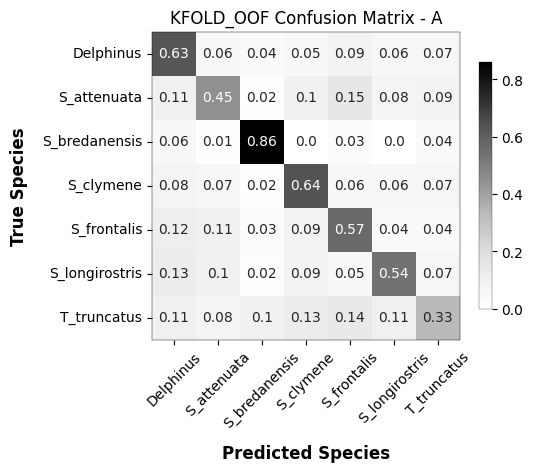


----- Preset B -----

Configuration:
	    rs_bal_1: 97645
	    rs_bal_2: 86067
	    rs_bal_3: 62224
	      rs_skf: 76360
	random_state: 92667
	n_estimators: 500
	max_features: log2
	   max_depth: 10
	      n_jobs: -1
	   oob_score: False
	min_samples_leaf: 1
	min_samples_split: 2

Initializing Random Forest Classifier model...

Iterating over each fold...
Fold 1:
Fold 2:
Fold 3:
Fold 4:
Fold 5:

End of Fold iteration.

[info] OOF table:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4622 entries, 0 to 4621
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Delphinus_KFOLD_5       4622 non-null   float64
 1   S_attenuata_KFOLD_5     4622 non-null   float64
 2   S_bredanensis_KFOLD_5   4622 non-null   float64
 3   S_clymene_KFOLD_5       4622 non-null   float64
 4   S_frontalis_KFOLD_5     4622 non-null   float64
 5   S_longirostris_KFOLD_5  4622 non-null   float64
 6   T_truncatus_KFOLD_5   

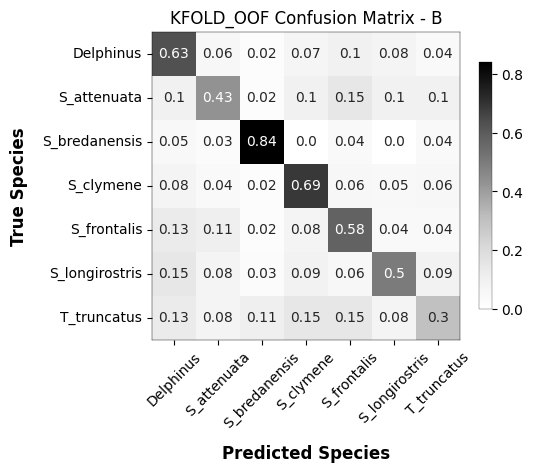


----- Preset C -----

Configuration:
	    rs_bal_1: 63454
	    rs_bal_2: 2116
	    rs_bal_3: 79859
	      rs_skf: 95598
	random_state: 34601
	n_estimators: 1000
	max_features: log2
	   max_depth: 15
	      n_jobs: -1
	   oob_score: False
	min_samples_leaf: 1
	min_samples_split: 2

Initializing Random Forest Classifier model...

Iterating over each fold...
Fold 1:
Fold 2:
Fold 3:
Fold 4:
Fold 5:

End of Fold iteration.

[info] OOF table:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4622 entries, 0 to 4621
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Delphinus_KFOLD_5       4622 non-null   float64
 1   S_attenuata_KFOLD_5     4622 non-null   float64
 2   S_bredanensis_KFOLD_5   4622 non-null   float64
 3   S_clymene_KFOLD_5       4622 non-null   float64
 4   S_frontalis_KFOLD_5     4622 non-null   float64
 5   S_longirostris_KFOLD_5  4622 non-null   float64
 6   T_truncatus_KFOLD_5   

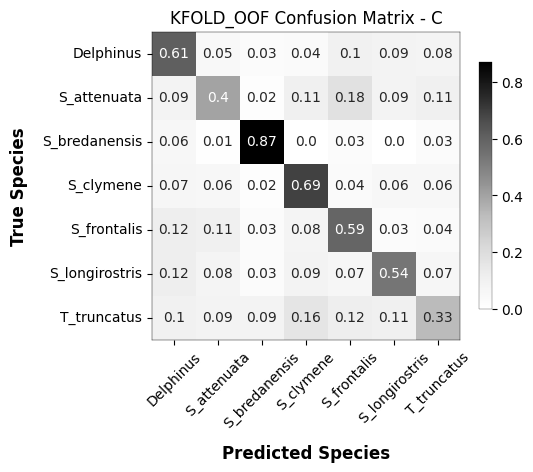


----- Preset D -----

Configuration:
	    rs_bal_1: 9771
	    rs_bal_2: 36711
	    rs_bal_3: 25882
	      rs_skf: 82486
	random_state: 51901
	n_estimators: 200
	max_features: 10
	   max_depth: 15
	      n_jobs: -1
	   oob_score: False
	min_samples_leaf: 1
	min_samples_split: 2

Initializing Random Forest Classifier model...

Iterating over each fold...
Fold 1:
Fold 2:
Fold 3:
Fold 4:
Fold 5:

End of Fold iteration.

[info] OOF table:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4622 entries, 0 to 4621
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Delphinus_KFOLD_5       4622 non-null   float64
 1   S_attenuata_KFOLD_5     4622 non-null   float64
 2   S_bredanensis_KFOLD_5   4622 non-null   float64
 3   S_clymene_KFOLD_5       4622 non-null   float64
 4   S_frontalis_KFOLD_5     4622 non-null   float64
 5   S_longirostris_KFOLD_5  4622 non-null   float64
 6   T_truncatus_KFOLD_5     4

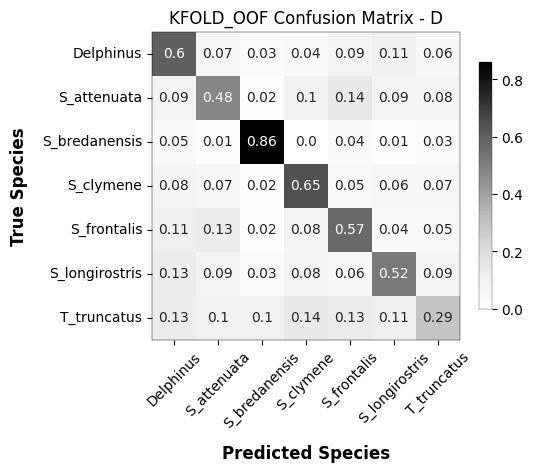


----- Preset E -----

Configuration:
	    rs_bal_1: 50978
	    rs_bal_2: 58443
	    rs_bal_3: 13185
	      rs_skf: 23093
	random_state: 25793
	n_estimators: 1000
	max_features: 0.75
	   max_depth: 15
	      n_jobs: -1
	   oob_score: False
	min_samples_leaf: 1
	min_samples_split: 2

Initializing Random Forest Classifier model...

Iterating over each fold...
Fold 1:
Fold 2:
Fold 3:
Fold 4:
Fold 5:

End of Fold iteration.

[info] OOF table:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4622 entries, 0 to 4621
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Delphinus_KFOLD_5       4622 non-null   float64
 1   S_attenuata_KFOLD_5     4622 non-null   float64
 2   S_bredanensis_KFOLD_5   4622 non-null   float64
 3   S_clymene_KFOLD_5       4622 non-null   float64
 4   S_frontalis_KFOLD_5     4622 non-null   float64
 5   S_longirostris_KFOLD_5  4622 non-null   float64
 6   T_truncatus_KFOLD_5  

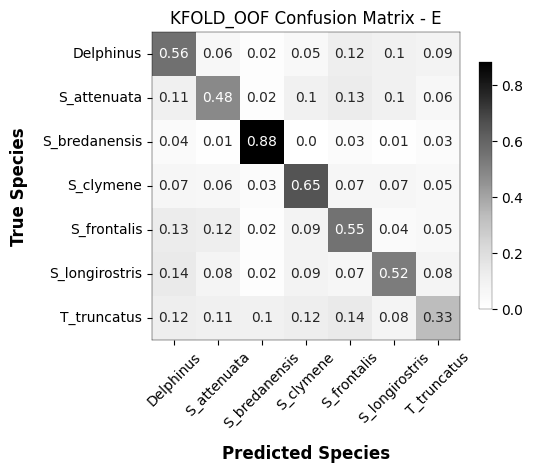

End of presets iteration.
Averaging results across presets...

Averaging classification reports...
[saving] d:\Documentos\GITHUB\Cetacea_Classifier_AParo\outputs\testing\KFOLD\_ABCDE_KFOLD_Averaged_Class_Report.csv

[info] Averaged KFOLD classification report:
               Labels  precision    recall  f1-score      support
0           Delphinus   0.217567  0.606957  0.320191   230.000000
1         S_attenuata   0.304352  0.449735  0.362668   378.000000
2       S_bredanensis   0.408906  0.860432  0.554338   139.000000
3           S_clymene   0.428225  0.663908  0.520522   435.000000
4         S_frontalis   0.784966  0.572269  0.661893  1767.000000
5      S_longirostris   0.653961  0.524675  0.582061   847.000000
6         T_truncatus   0.535651  0.315012  0.396645   826.000000
7            accuracy   0.526569  0.526569  0.526569     0.526569
8   balanced_accuracy   0.570427       NaN       NaN          NaN
9           macro avg   0.476233  0.570427  0.485474  4622.000000
10       weig

In [19]:
print(f"{sep}\nKFOLD Classification:\n{sep}")
KFOLD_DIR = os.path.join(RUN_DIR, "KFOLD")
os.makedirs(KFOLD_DIR, exist_ok=True)
print_fold_stats = False # False to ommit each fold individual statistics
configs_global = {'oob_score': False,'min_samples_leaf': 1, 'min_samples_split': 2}

KFOLD_PRESETS = {
                "preset_labels":[   "A",    "B",    "C",   "D",   "E"], # Preset labels
                # Balancing Random states
                "rs_bal_1":     [ 56450,  97645,  63454,  9771, 50978], # 1st Random state for balancing methods (e.g. SMOTE/undersampling/oversampling)
                "rs_bal_2":     [  6273,  86067,   2116, 36711, 58443], # 2nd Random state for balancing methods (e.g. SMOTE/undersampling/oversampling)
                "rs_bal_3":     [  7833,  62224,  79859, 25882, 13185], # 3rd Random state for balancing methods (e.g. SMOTE/undersampling/oversampling)
                "rs_skf":       [ 31853,  76360,  95598, 82486, 23093], # Random state for stratified K-fold splitting
                # RandomForest hyperparameters
                "random_state": [ 13444,  92667,  34601, 51901, 25793], # Random state for the RandomForest classifier
                "n_estimators": [   200,    500,   1000,   200,  1000], # number of trees
                "max_features": ["log2", "log2", "log2",    10,  0.75], # feature selection strategy
                "max_depth":    [    20,     10,     15,    15,    15], # maximum tree depth
                    }

models_kfold_pklfile = os.path.join(KFOLD_DIR, f"_{''.join(KFOLD_PRESETS['preset_labels'])}_KFOLD_RFCmodels.pkl")

if predict_only: # prediction mode
    print("\n[info] Predict only mode enabled - skipping KFOLD training.\n\tLoading pre-trained models...")
    presets_models_kfold = joblib.load(models_kfold_pklfile)
else: # training mode
    presets_models_kfold = {} # to store the fit models for each preset
    presets_report_kfold = [] # to store the classification report for each preset
    presets_probs_kfold  = [] # to store the probabilities for each preset

    print('Iterating over each preset:')
    for i, preset in enumerate(KFOLD_PRESETS['preset_labels']):
        print(f"\n{sep}\n----- Preset {preset} -----\n")
        cfg, rfc_params = get_preset_configs(KFOLD_PRESETS, KFOLD_DIR, preset, grouping_type='KFOLD', **configs_global)

        print("\nInitializing Random Forest Classifier model...")  
        RFC = RandomForestClassifier(**rfc_params)
        SKF = StratifiedKFold(n_splits=5, shuffle=True, random_state= cfg["rs_skf"]) # Create Stratified K-Fold object
        n_samples = len(X)

        # Iteration over each fold
        print('\nIterating over each fold...')
        oof_probabilities = np.zeros((X.shape[0], len(np.unique(Y)))) # Prepare to collect out-of-fold probabilities
        fold_models       = [] # to store the fit models for each fold
        for fold_idx, (train_index, test_index) in enumerate(SKF.split(X.drop(columns=['EncounterNumber', 'KnownSpecies']), Y)):
            print(f'Fold {fold_idx+1}:')
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train, y_test = Y.iloc[train_index], Y.iloc[test_index]

            # Calculate weights for balancing
            weights = {}
            for class_label in y_train.unique():
                # Use EncounterNumber for group calculations
                group_sizes = X_train[X_train['KnownSpecies'] == class_label].groupby('EncounterNumber').size()
                inverse_group_sizes  = 1 / group_sizes
                weights[class_label] = (inverse_group_sizes / inverse_group_sizes.sum()).to_dict()
            
            # Determine target class size and balance the training data within the fold        
            target_class_size = y_train.value_counts().min() 
            X_train_balanced, y_train_balanced = balance_train_data_kfold(X_train, weights, target_class_size,
                                                                        RS_bal_1= cfg["rs_bal_1"], RS_bal_2= cfg["rs_bal_2"], RS_bal_3= cfg["rs_bal_3"])
            n_train_bal_groups = len(X_train_balanced['EncounterNumber'].unique())
            # Remove 'EncounterNumber' and 'KnownSpecies' to train+fit the model and predict test 
            X_train_balanced = X_train_balanced.drop(columns=['EncounterNumber', 'KnownSpecies'], errors='ignore')
            X_test_features  = X_test.drop(columns=['EncounterNumber', 'KnownSpecies'], errors='ignore')
            RFC.fit(X_train_balanced, y_train_balanced) # Train the model on the balanced training fold
            fold_models.append(RFC)  # Store the trained model for this fold
            oof_probabilities[test_index] = RFC.predict_proba(X_test_features)

            if print_fold_stats:
                print('=' * 25)
                y_pred = RFC.predict(X_test_features)
                print("\t[info] Classification report:") # Detailed classification report for this fold
                class_report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
                print(f'\t\tOverall Accuracy:  {class_report['accuracy']}')
                print(f'\t\tBalanced Accuracy: {balanced_accuracy_score(y_test, y_pred)}')
                print(f'\t\tPrecision Macro:   {class_report['macro avg']['precision']}')
                print(f'\t\tRecall Macro:      {class_report['macro avg']['recall']}')
                print(f'\t\tF1 Macro:          {class_report['macro avg']['f1-score']}')
                print(f'\t\tF1 Weighted:       {class_report['weighted avg']['f1-score']}')
                print("\ntTraining set statistics:")
                total_train = len(X_train)
                print(f'\t\tTraining indexes: {train_index}')
                print(f'\t\tTotal training ocurrences: {total_train} ({total_train / n_samples:.2%})')
                print(f'\t\tTotal number of species: {len(y_train.unique())}')
                print(f'\t\tTotal number of events:  {len(X_train['EncounterNumber'].unique())}')
                print(y_train.value_counts())
                print("\n\tBalanced training set statistics:")
                total_train_bal = len(X_train_balanced)
                print(f'\t\tTotal training ocurrences: {total_train_bal} ({total_train_bal / n_samples:.2%})')
                print(f'\t\tTotal number of species: {len(y_train_balanced.unique())}')
                print(f'\t\tTotal number of events:  {n_train_bal_groups}')
                print(y_train_balanced.value_counts())
                print("\n\tTesting set statistics:")
                test_species_counts = y_test.value_counts()
                total_test = len(X_test)
                print(f'\t\tTotal testing ocurrences: {total_test} ({total_test / n_samples:.2%})')
                print(f'\t\tTotal number of species: {len(y_test.unique())}')
                print(f'\t\tTotal number of events:  {len(X_test['EncounterNumber'].unique())}')
                print(test_species_counts)
                labels_no_predictions = []
                for label, metrics in class_report.items(): # Find labels with no predictions
                    if isinstance(metrics, dict) and metrics['precision'] == 0 and test_species_counts.get(label, 0) > 0:
                        labels_no_predictions.append(label)
                if labels_no_predictions:
                    print(f"\t\tLabels with no predictions: {labels_no_predictions}")
                print('=' * 25)
        print('\nEnd of Fold iteration.\n','=' * 50)
        presets_models_kfold[preset] = fold_models # Store all models for this preset

        # --- Probabilities table and classifier results ---
        # Classification Out Of Folds (OOF) Probabilities and Weights
        # `oof_probabilities` [shape (n_samples, n_classes)] contains the predicted probabilities for all instances in the original dataset.
        class_labels = RFC.classes_      # Get the class labels from the trained model
        oof_df = pd.DataFrame(oof_probabilities, columns=class_labels)
        oof_df['Species_Classification'] = oof_df.idxmax(axis=1)
        if 'UID' in MASTERSHEET.columns:
            oof_df['UID']         = MASTERSHEET['UID'].values
        else: 
            oof_df['UID']         = MASTERSHEET.index.values
        oof_df['KnownSpecies']    = MASTERSHEET['KnownSpecies'].values  
        oof_df['EncounterNumber'] = MASTERSHEET['EncounterNumber'].values 
        oof_df.columns = [col + '_KFOLD_5' if i < n_species else col for i, col in enumerate(oof_df.columns)]
        print('\n[info] OOF table:')
        oof_df.info()
        # --- Saving OOF Probabilities table ---
        oof_probs_path = os.path.join(KFOLD_DIR, f'{preset}_KFOLD_OOF_Class_Probs.csv')
        print(f"\n[saving] OOF probabilities at {oof_probs_path}")
        oof_df.to_csv(oof_probs_path, index = False)
        presets_probs_kfold.append(oof_df)
        
        # --- Classification report ---
        y_pred_oof  = oof_df['Species_Classification']
        y_test_oof  = oof_df['KnownSpecies']
        bal_acc_off = balanced_accuracy_score(y_test_oof, y_pred_oof)
        class_report_oof = classification_report(y_test_oof, y_pred_oof, output_dict=True, labels = class_labels )
        class_report_oof_df = pd.DataFrame(class_report_oof).transpose()
        class_report_oof_df['Labels'] = class_report_oof_df.index
        class_report_oof_df = class_report_oof_df[['Labels', 'precision', 'recall', 'f1-score', 'support']] # Reorder columns to have labels first
        # Create balanced_accuracy row (use np.nan instead of None)
        new_row = pd.DataFrame({'Labels': ['balanced_accuracy'], 'precision': [bal_acc_off], 
                                'recall': [np.nan],'f1-score': [np.nan],'support': [np.nan] })
        new_row = new_row[class_report_oof_df.columns]# Ensure correct column order & metadata matching
        class_report_oof_df = pd.concat([class_report_oof_df, new_row], ignore_index=True)
        # Saving report
        print(f"\n[info] OOF classification report:\n{class_report_oof_df}")
        report_path = os.path.join(KFOLD_DIR, f'{preset}_KFOLD_OOF_Class_Report.csv')
        print(f"\n[saving] at {report_path}")
        class_report_oof_df.to_csv(report_path, index = False)
        presets_report_kfold.append(class_report_oof_df)
        
        # --- Confusion Matrix plot ---
        # Heatmap OFF \ WEIGHTS        
        conf_matrix_kfold = confusion_matrix(y_test_oof, y_pred_oof, labels = class_labels)
        conf_matrix_adjusted_kfold = adjust_confusion_matrix(conf_matrix_kfold)
        plot_confusion_matrix_heatmap(matrix=conf_matrix_adjusted_kfold, class_labels=class_labels,
                preset=preset,save_dir=KFOLD_DIR,grouping="KFOLD_OOF")
    
    # --- Averaging class report and probabilities across presets ---
    print(f'{sep}\nEnd of presets iteration.\nAveraging results across presets...\n{sep}')

    averaged_class_report_fold = average_presets_reports(tables=presets_report_kfold,
        presets_labels=KFOLD_PRESETS['preset_labels'], out_dir=KFOLD_DIR, method_tag="KFOLD")
    print(f"\n[info] Averaged KFOLD classification report:\n{averaged_class_report_fold}")

    averaged_probs_kfold = average_presets_probs(tables=presets_probs_kfold,
        presets_labels=KFOLD_PRESETS['preset_labels'], out_dir=KFOLD_DIR, method_tag="KFOLD")

    print(f'\n[saving] KFOLD RFC models at {models_kfold_pklfile}')
    joblib.dump(presets_models_kfold, models_kfold_pklfile)
print(f"\n{sep}\nEnd of KFOLD Classification.\n{sep}")

## Leave One Group Out (LOGO)
-Individual (Whistles) and Events (Encounter) level classification

  Leave One Group Out (LOGO) Classification:
Iterating over each preset:
---------- Preset A ----------
Configuration:
	      rs_bal: 26225
	random_state: 78978
	n_estimators: 500
	max_features: log2
	   max_depth: 10
	      n_jobs: -1
	   oob_score: True
	min_samples_leaf: 1
	min_samples_split: 2

Initializing Random Forest Classifier model...

Iteration for each KnownSpecies:

		Delphinus:

			Iteration for each EncounterNumber:
				PMC_12_A15:
					[nbal] = 139
				PMC_12_A33:
					[nbal] = 139
				PMC_12_A46:
					[nbal] = 139
				PMC_12_A47:
					[nbal] = 139
				PMC_12_A62:
					[nbal] = 139
				PMC_3_A68:
					[nbal] = 139
				PMC_6_A51:
					[nbal] = 139
				PMC_9_A102:
					[nbal] = 139

		S_attenuata:

			Iteration for each EncounterNumber:
				Per_02_A05:
					[nbal] = 139
				Per_02_A23:
					[nbal] = 139
				Per_02_A56:
					[nbal] = 139
				PMC_12_A42:
					[nbal] = 139
				PMC_1_A13:
					[nbal] = 139
				PMC_1_A48:
					[nbal] = 139
				PMC_2_A14:
					[nbal] = 139
				

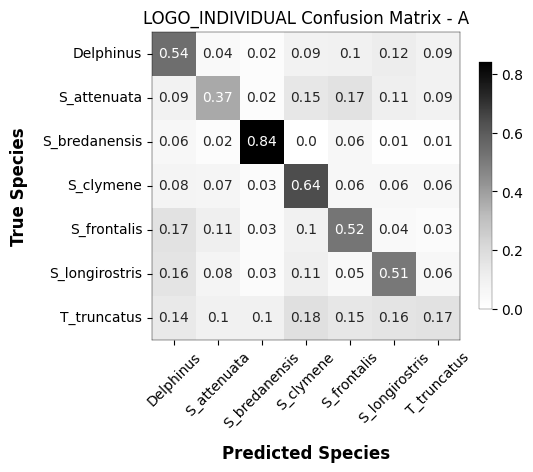

LOGO Events Classification.

[info] Events Probabilities table shape: (4622, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4622 entries, 0 to 4621
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Delphinus_LOGO_EVENT       4622 non-null   float64
 1   S_attenuata_LOGO_EVENT     4622 non-null   float64
 2   S_bredanensis_LOGO_EVENT   4622 non-null   float64
 3   S_clymene_LOGO_EVENT       4622 non-null   float64
 4   S_frontalis_LOGO_EVENT     4622 non-null   float64
 5   S_longirostris_LOGO_EVENT  4622 non-null   float64
 6   T_truncatus_LOGO_EVENT     4622 non-null   float64
 7   Species_Classification     4622 non-null   object 
 8   UID                        4622 non-null   int64  
 9   EncounterNumber            4622 non-null   object 
 10  KnownSpecies               4622 non-null   object 
dtypes: float64(7), int64(1), object(3)
memory usage: 397.3+ KB

[saving] at d:\Docu

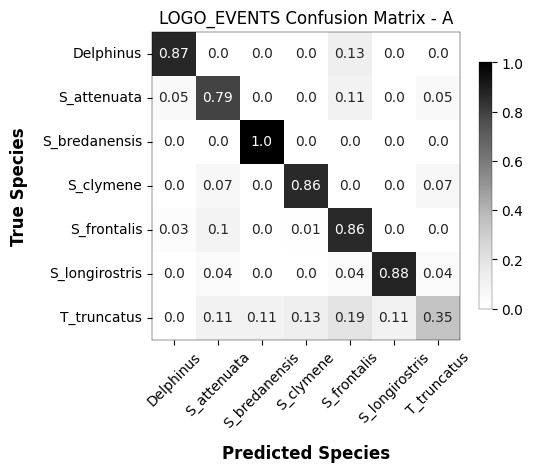

---------- Preset B ----------
Configuration:
	      rs_bal: 64386
	random_state: 52029
	n_estimators: 1000
	max_features: 0.5
	   max_depth: 10
	      n_jobs: -1
	   oob_score: True
	min_samples_leaf: 1
	min_samples_split: 2

Initializing Random Forest Classifier model...

Iteration for each KnownSpecies:

		Delphinus:

			Iteration for each EncounterNumber:
				PMC_12_A15:
					[nbal] = 139
				PMC_12_A33:
					[nbal] = 139
				PMC_12_A46:
					[nbal] = 139
				PMC_12_A47:
					[nbal] = 139
				PMC_12_A62:
					[nbal] = 139
				PMC_3_A68:
					[nbal] = 139
				PMC_6_A51:
					[nbal] = 139
				PMC_9_A102:
					[nbal] = 139

		S_attenuata:

			Iteration for each EncounterNumber:
				Per_02_A05:
					[nbal] = 139
				Per_02_A23:
					[nbal] = 139
				Per_02_A56:
					[nbal] = 139
				PMC_12_A42:
					[nbal] = 139
				PMC_1_A13:
					[nbal] = 139
				PMC_1_A48:
					[nbal] = 139
				PMC_2_A14:
					[nbal] = 139
				PMC_4_A32:
					[nbal] = 139
				PMC_8_A101:
					[nbal] = 139
				PMC_8_

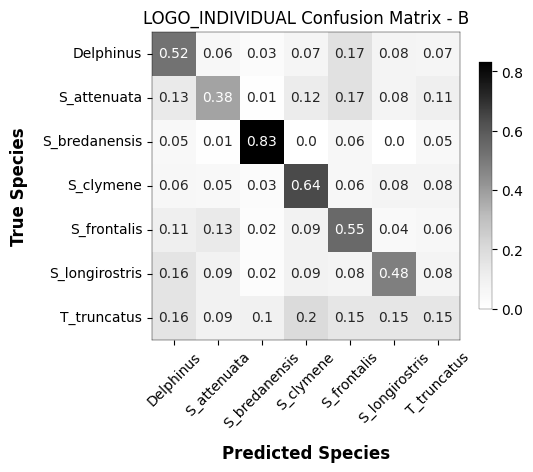

LOGO Events Classification.

[info] Events Probabilities table shape: (4622, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4622 entries, 0 to 4621
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Delphinus_LOGO_EVENT       4622 non-null   float64
 1   S_attenuata_LOGO_EVENT     4622 non-null   float64
 2   S_bredanensis_LOGO_EVENT   4622 non-null   float64
 3   S_clymene_LOGO_EVENT       4622 non-null   float64
 4   S_frontalis_LOGO_EVENT     4622 non-null   float64
 5   S_longirostris_LOGO_EVENT  4622 non-null   float64
 6   T_truncatus_LOGO_EVENT     4622 non-null   float64
 7   Species_Classification     4622 non-null   object 
 8   UID                        4622 non-null   int64  
 9   EncounterNumber            4622 non-null   object 
 10  KnownSpecies               4622 non-null   object 
dtypes: float64(7), int64(1), object(3)
memory usage: 397.3+ KB

[saving] at d:\Docu

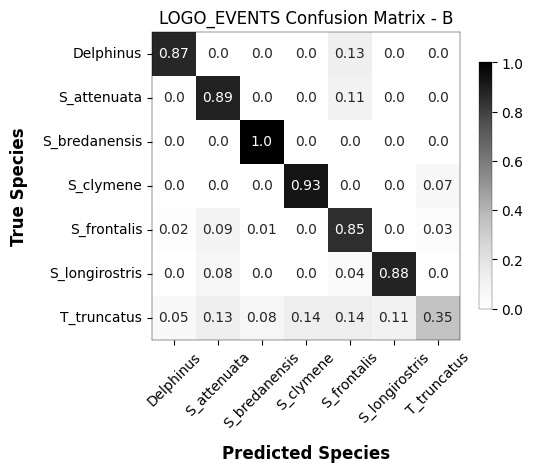

---------- Preset C ----------
Configuration:
	      rs_bal: 61999
	random_state: 78121
	n_estimators: 1000
	max_features: log2
	   max_depth: 30
	      n_jobs: -1
	   oob_score: True
	min_samples_leaf: 1
	min_samples_split: 2

Initializing Random Forest Classifier model...

Iteration for each KnownSpecies:

		Delphinus:

			Iteration for each EncounterNumber:
				PMC_12_A15:
					[nbal] = 139
				PMC_12_A33:
					[nbal] = 139
				PMC_12_A46:
					[nbal] = 139
				PMC_12_A47:
					[nbal] = 139
				PMC_12_A62:
					[nbal] = 139
				PMC_3_A68:
					[nbal] = 139
				PMC_6_A51:
					[nbal] = 139
				PMC_9_A102:
					[nbal] = 139

		S_attenuata:

			Iteration for each EncounterNumber:
				Per_02_A05:
					[nbal] = 139
				Per_02_A23:
					[nbal] = 139
				Per_02_A56:
					[nbal] = 139
				PMC_12_A42:
					[nbal] = 139
				PMC_1_A13:
					[nbal] = 139
				PMC_1_A48:
					[nbal] = 139
				PMC_2_A14:
					[nbal] = 139
				PMC_4_A32:
					[nbal] = 139
				PMC_8_A101:
					[nbal] = 139
				PMC_8

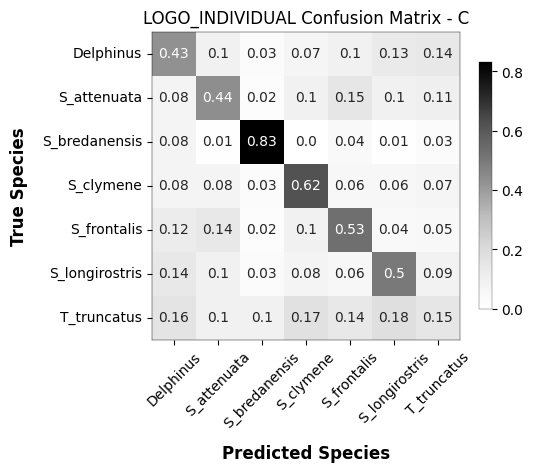

LOGO Events Classification.

[info] Events Probabilities table shape: (4622, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4622 entries, 0 to 4621
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Delphinus_LOGO_EVENT       4622 non-null   float64
 1   S_attenuata_LOGO_EVENT     4622 non-null   float64
 2   S_bredanensis_LOGO_EVENT   4622 non-null   float64
 3   S_clymene_LOGO_EVENT       4622 non-null   float64
 4   S_frontalis_LOGO_EVENT     4622 non-null   float64
 5   S_longirostris_LOGO_EVENT  4622 non-null   float64
 6   T_truncatus_LOGO_EVENT     4622 non-null   float64
 7   Species_Classification     4622 non-null   object 
 8   UID                        4622 non-null   int64  
 9   EncounterNumber            4622 non-null   object 
 10  KnownSpecies               4622 non-null   object 
dtypes: float64(7), int64(1), object(3)
memory usage: 397.3+ KB

[saving] at d:\Docu

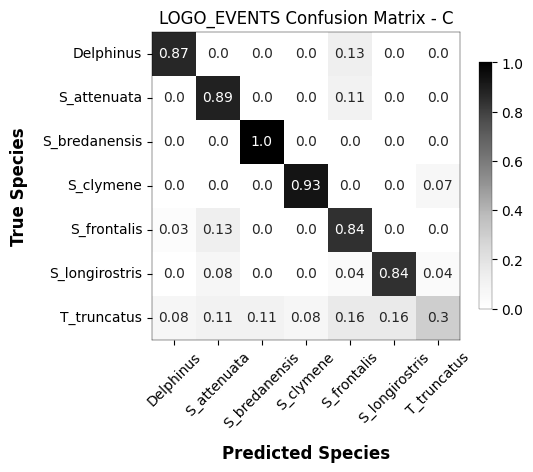

---------- Preset D ----------
Configuration:
	      rs_bal: 71437
	random_state: 78113
	n_estimators: 500
	max_features: 0.5
	   max_depth: 10
	      n_jobs: -1
	   oob_score: True
	min_samples_leaf: 1
	min_samples_split: 2

Initializing Random Forest Classifier model...

Iteration for each KnownSpecies:

		Delphinus:

			Iteration for each EncounterNumber:
				PMC_12_A15:
					[nbal] = 139
				PMC_12_A33:
					[nbal] = 139
				PMC_12_A46:
					[nbal] = 139
				PMC_12_A47:
					[nbal] = 139
				PMC_12_A62:
					[nbal] = 139
				PMC_3_A68:
					[nbal] = 139
				PMC_6_A51:
					[nbal] = 139
				PMC_9_A102:
					[nbal] = 139

		S_attenuata:

			Iteration for each EncounterNumber:
				Per_02_A05:
					[nbal] = 139
				Per_02_A23:
					[nbal] = 139
				Per_02_A56:
					[nbal] = 139
				PMC_12_A42:
					[nbal] = 139
				PMC_1_A13:
					[nbal] = 139
				PMC_1_A48:
					[nbal] = 139
				PMC_2_A14:
					[nbal] = 139
				PMC_4_A32:
					[nbal] = 139
				PMC_8_A101:
					[nbal] = 139
				PMC_8_A

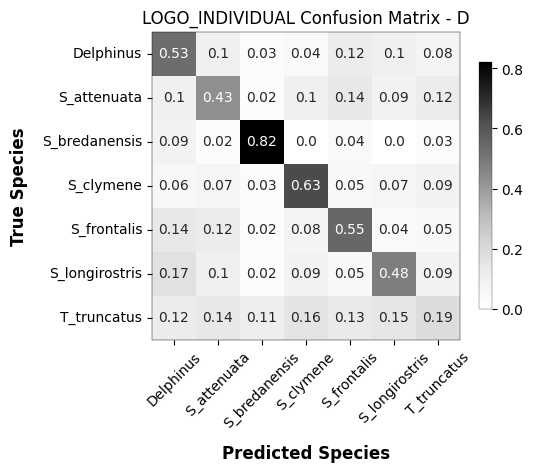

LOGO Events Classification.

[info] Events Probabilities table shape: (4622, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4622 entries, 0 to 4621
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Delphinus_LOGO_EVENT       4622 non-null   float64
 1   S_attenuata_LOGO_EVENT     4622 non-null   float64
 2   S_bredanensis_LOGO_EVENT   4622 non-null   float64
 3   S_clymene_LOGO_EVENT       4622 non-null   float64
 4   S_frontalis_LOGO_EVENT     4622 non-null   float64
 5   S_longirostris_LOGO_EVENT  4622 non-null   float64
 6   T_truncatus_LOGO_EVENT     4622 non-null   float64
 7   Species_Classification     4622 non-null   object 
 8   UID                        4622 non-null   int64  
 9   EncounterNumber            4622 non-null   object 
 10  KnownSpecies               4622 non-null   object 
dtypes: float64(7), int64(1), object(3)
memory usage: 397.3+ KB

[saving] at d:\Docu

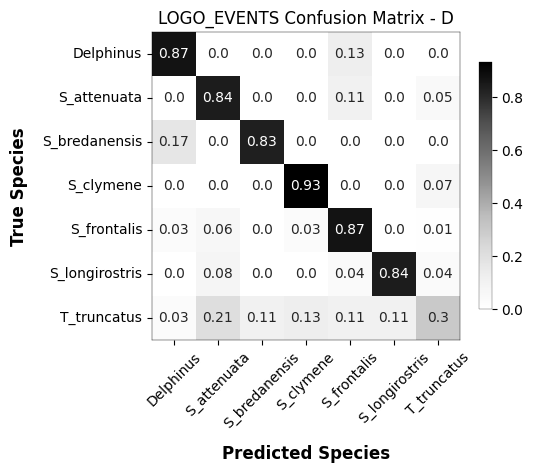

---------- Preset E ----------
Configuration:
	      rs_bal: 1972
	random_state: 72661
	n_estimators: 1000
	max_features: sqrt
	   max_depth: 10
	      n_jobs: -1
	   oob_score: True
	min_samples_leaf: 1
	min_samples_split: 2

Initializing Random Forest Classifier model...

Iteration for each KnownSpecies:

		Delphinus:

			Iteration for each EncounterNumber:
				PMC_12_A15:
					[nbal] = 139
				PMC_12_A33:
					[nbal] = 139
				PMC_12_A46:
					[nbal] = 139
				PMC_12_A47:
					[nbal] = 139
				PMC_12_A62:
					[nbal] = 139
				PMC_3_A68:
					[nbal] = 139
				PMC_6_A51:
					[nbal] = 139
				PMC_9_A102:
					[nbal] = 139

		S_attenuata:

			Iteration for each EncounterNumber:
				Per_02_A05:
					[nbal] = 139
				Per_02_A23:
					[nbal] = 139
				Per_02_A56:
					[nbal] = 139
				PMC_12_A42:
					[nbal] = 139
				PMC_1_A13:
					[nbal] = 139
				PMC_1_A48:
					[nbal] = 139
				PMC_2_A14:
					[nbal] = 139
				PMC_4_A32:
					[nbal] = 139
				PMC_8_A101:
					[nbal] = 139
				PMC_8_

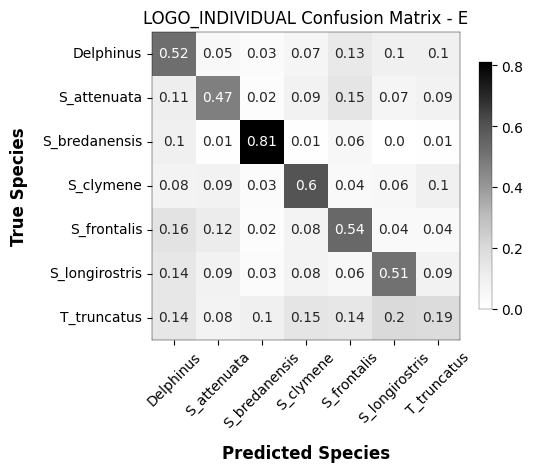

LOGO Events Classification.

[info] Events Probabilities table shape: (4622, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4622 entries, 0 to 4621
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Delphinus_LOGO_EVENT       4622 non-null   float64
 1   S_attenuata_LOGO_EVENT     4622 non-null   float64
 2   S_bredanensis_LOGO_EVENT   4622 non-null   float64
 3   S_clymene_LOGO_EVENT       4622 non-null   float64
 4   S_frontalis_LOGO_EVENT     4622 non-null   float64
 5   S_longirostris_LOGO_EVENT  4622 non-null   float64
 6   T_truncatus_LOGO_EVENT     4622 non-null   float64
 7   Species_Classification     4622 non-null   object 
 8   UID                        4622 non-null   int64  
 9   EncounterNumber            4622 non-null   object 
 10  KnownSpecies               4622 non-null   object 
dtypes: float64(7), int64(1), object(3)
memory usage: 397.3+ KB

[saving] at d:\Docu

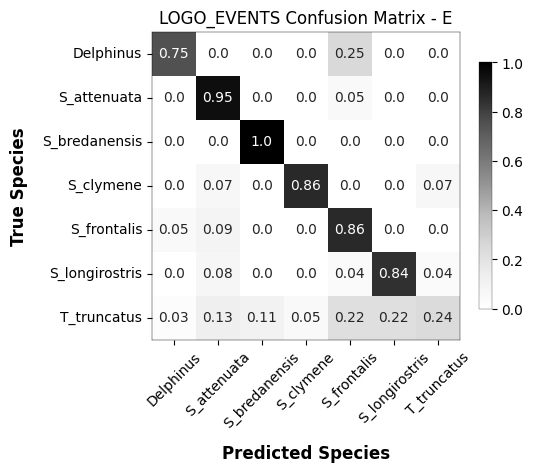

End of presets iteration.
Averaging results across presets...

Averaging classification reports...
[saving] d:\Documentos\GITHUB\Cetacea_Classifier_AParo\outputs\testing\LOGO\_ABCDE_LOGO_INDIVIDUAL_Averaged_Class_Report.csv

[info] Averaged LOGO INDIVIDUAL classification report:
               Labels  precision    recall  f1-score      support
0           Delphinus   0.167985  0.506957  0.252192   230.000000
1         S_attenuata   0.267008  0.418519  0.325640   378.000000
2       S_bredanensis   0.393699  0.827338  0.533468   139.000000
3           S_clymene   0.389532  0.626207  0.479831   435.000000
4         S_frontalis   0.767771  0.536955  0.631860  1767.000000
5      S_longirostris   0.587318  0.496812  0.538162   847.000000
6         T_truncatus   0.365078  0.171186  0.232642   826.000000
7            accuracy   0.470186  0.470186  0.470186     0.470186
8   balanced_accuracy   0.511996       NaN       NaN          NaN
9           macro avg   0.419770  0.511996  0.427685  4622.0

In [8]:
print(f'{sep}\n  Leave One Group Out (LOGO) Classification:\n{sep}')
LOGO_DIR = os.path.join(RUN_DIR, "LOGO")
os.makedirs(LOGO_DIR, exist_ok=True)
configs_global = {'oob_score': False,'min_samples_leaf': 1, 'min_samples_split': 2}

LOGO_PRESETS = {
                "preset_labels": [   "A",   "B",    "C",   "D",    "E"], # Preset labels
                "rs_bal":        [ 26225, 64386,  61999, 71437,   1972], # Random state for balancing methods (e.g. SMOTE/undersampling/oversampling)
                # RandomForest hyperparameters
                "random_state":  [ 78978, 52029,  78121, 78113,  72661], # Random state for the RandomForest classifier
                "n_estimators":  [   500,  1000,   1000,   500,   1000], # number of trees
                "max_features":  ["log2",   0.5, "log2",   0.5, 'sqrt'], # feature selection strategy
                "max_depth":     [    10,    10,     30,    10,     10], # maximum tree depth
                    }

models_logo_ind_pklfile = os.path.join(LOGO_DIR, f"_{''.join(LOGO_PRESETS['preset_labels'])}_LOGO_INDIVIDUAL_RFCmodels.pkl")
models_logo_ev_pklfile  = os.path.join(LOGO_DIR, f"_{''.join(LOGO_PRESETS['preset_labels'])}_LOGO_EVENT_RFCmodels.pkl")

if predict_only: # prediction mode
    print("\n[info] Predict only mode enabled - skipping FOLD training.\n\tLoading pre-trained models...")
    presets_models_logo_ind = joblib.load(models_logo_ind_pklfile)
    presets_models_logo_ev  = joblib.load(models_logo_ev_pklfile)

else: # training mode
    presets_models_logo_ind  = {} # to store the fit models for each preset (individual)
    presets_models_logo_ev   = {} # to store the fit models for each preset (event-level)
    presets_report_logo_ind  = [] # to store the classification report for each preset (individual)
    presets_report_logo_ev   = [] # to store the classification report for each preset (event-level)
    presets_probs_logo_ind   = [] # to store the probabilities for each preset (individual)
    presets_probs_logo_ev    = [] # to store the probabilities for each preset (event-level)

    print('Iterating over each preset:')
    for i, preset in enumerate(LOGO_PRESETS['preset_labels']):
        print(f"{sep}\n---------- Preset {preset} ----------")
        cfg, rfc_params = get_preset_configs(LOGO_PRESETS, LOGO_DIR, preset, grouping_type='LOGO', **configs_global)

        print("\nInitializing Random Forest Classifier model...")
        RFC = RandomForestClassifier(**rfc_params)
        preset_results, fitted_models = testing_loop(mastersheet=X,RFC=RFC, factors=factors, sampler_seed=cfg["rs_bal"])
        presets_models_logo_ind[preset] = fitted_models

        # --- Probabilities table and Classification report ---
        y_true, y_pred, class_labels, probs_individual = collect_true_pred_and_probs(preset_results, probs_suffix="_LOGO_IND")
        print(f"[info] Individual class-prob table shape: {probs_individual.shape}")
        probs_individual.info()
        # Saving individual probabilities table 
        probs_ind_path = os.path.join(LOGO_DIR, f"{preset}_LOGO_INDIVIDUAL_Class_Probs.csv")
        print(f"[saving] at {probs_ind_path}")
        probs_individual.to_csv(probs_ind_path, index=False)
        presets_probs_logo_ind.append(probs_individual)

        # --- Classification report ---
        report_dict = classification_report(y_true, y_pred, output_dict=True, labels=class_labels, zero_division=0)
        report_df   = (pd.DataFrame(report_dict).transpose().rename_axis("Labels").reset_index())
        cols = ["Labels", "precision", "recall", "f1-score", "support"] # Keep only useful cols
        class_report_individual = report_df[[c for c in cols if c in report_df.columns]]
        # class_report_individual = class_report_individual[cols]
        balanced_acc = balanced_accuracy_score(y_true, y_pred)  # Balanced accuracy row
        # new_row = pd.DataFrame([["balanced_accuracy", balanced_acc, None, None, None]],columns=class_report_individual.columns)
        
        new_row = pd.DataFrame({'Labels': ['balanced_accuracy'], 'precision': [balanced_acc], 
                                'recall': [np.nan],'f1-score': [np.nan],'support': [np.nan] })
        new_row = new_row[class_report_individual.columns] # Ensure correct column order & metadata matching
        
        class_report_individual = pd.concat([class_report_individual, new_row], ignore_index=True)
        # Saving individual classification report
        print(f'\n[info] LOGO Individual Classification Report:\n{class_report_individual}')
        report_ind_path = os.path.join(LOGO_DIR, f'{preset}_LOGO_INDIVIDUAL_Class_Report.csv')
        print(f"\n[saving] at {report_ind_path}")
        class_report_individual.to_csv(report_ind_path, index = False)
        presets_report_logo_ind.append(class_report_individual)

        # --- Confusion Matrix plot ---
        conf_matrix = confusion_matrix(y_true, y_pred, labels=class_labels)
        conf_matrix_adjusted = adjust_confusion_matrix(conf_matrix)
        plot_confusion_matrix_heatmap(matrix=conf_matrix_adjusted, class_labels=class_labels,
                    preset=preset,save_dir=LOGO_DIR,grouping="LOGO_INDIVIDUAL")
        
        ####################################################################################################
        # --- LOGO Events Classification ---
        print(f"{sep}\nLOGO Events Classification.\n")

        # Events Probabilities table 
        probs_events = make_event_level_probs(probs_individual, suffix="_LOGO_EVENT")
        print(f"[info] Events Probabilities table shape: {probs_events.shape}")
        probs_events.info()
        probs_evts_path = os.path.join(LOGO_DIR, f"{preset}_LOGO_EVENTS_Class_Probs.csv")
        print(f"\n[saving] at {probs_evts_path}")
        probs_events.to_csv(probs_evts_path, index=False)
        presets_probs_logo_ev.append(probs_events)

        # ---- Summarize each encounter from Tree_votes ----
        OOB_score_list, enc_summary_frames = [], []
        for species, res in preset_results.items():
            # gather OOB scores
            OOB_score_list.extend(res.get("OOB_score", []))
            tree_votes_list = res["Tree_votes"]           # list[pd.DataFrame]
            encounter_ids   = res["EncounterNumber"]      # list[str], same length
            summaries = []
            for votes_df, enc_id in zip(tree_votes_list, encounter_ids):
                s = summarize_encounter_votes(votes_df, actual_species=species)
                s["KnownSpecies"] = species
                s["EncounterNumber"] = enc_id
                summaries.append(s)
            df_sp = pd.DataFrame(summaries)
            df_sp["Correct"] = (df_sp["Species_classification"] == df_sp["KnownSpecies"])
            enc_summary_frames.append(df_sp)
        Enc_Class_results = pd.concat(enc_summary_frames, ignore_index=True) # Concatenate all species

        # ---- Event Classification Report and Metrics ----
        y_test_ev = Enc_Class_results["KnownSpecies"]
        y_pred_ev = Enc_Class_results["Species_classification"]
        class_ev  = Enc_Class_results["KnownSpecies"].unique()
        class_report_events = classification_report(y_test_ev, y_pred_ev, output_dict=True, labels=class_ev)
        class_report_events = (pd.DataFrame(class_report_events).transpose().rename_axis("Labels")
                                .reset_index()[["Labels", "precision", "recall", "f1-score", "support"]])

        mean_OOB = float(np.mean(OOB_score_list)) if OOB_score_list else np.nan
        sd_OOB   = float(np.std(OOB_score_list))  if OOB_score_list else np.nan
        accuracy = 100.0 * accuracy_score(y_test_ev, y_pred_ev)
        balanced_acc = balanced_accuracy_score(y_test_ev, y_pred_ev)
        # Create balanced_accuracy row (use np.nan instead of None)
        new_row = pd.DataFrame({'Labels': ['balanced_accuracy'], 'precision': [balanced_acc], 
                                'recall': [np.nan],'f1-score': [np.nan],'support': [np.nan] })
        new_row = new_row[class_report_events.columns] # Ensure correct column order & metadata matching
        class_report_events = pd.concat([class_report_events, new_row], ignore_index=True) # add balanced_accuracy row
        print('\n[info] Events Classification Report:')
        print(f"\tEvent Accuracy: {accuracy:.2f}%")
        print(f"\tMean OOB: {mean_OOB:.2f}")
        print(f"\tSD OOB: {sd_OOB:.2f}\n")
        print(class_report_events)
        report_events_path = os.path.join(LOGO_DIR, f'{preset}_LOGO_EVENTS_Class_Report.csv')
        print(f"\n[saving] at {report_events_path}")
        class_report_events.to_csv(report_events_path, index = False)
        presets_report_logo_ev.append(class_report_events)

        # --- Confusion Matrix plot ---
        conf_matrix_ev = confusion_matrix(y_test_ev, y_pred_ev, labels=class_ev)
        conf_matrix_ev_adjusted = adjust_confusion_matrix(conf_matrix_ev) 
        plot_confusion_matrix_heatmap(matrix=conf_matrix_ev_adjusted, class_labels=class_labels,
                    preset=preset,save_dir=LOGO_DIR,grouping="LOGO_EVENTS")
    
    # --- Averaging class report and probabilities across presets ---
    print(f'{sep}\nEnd of presets iteration.\nAveraging results across presets...\n{sep}')

    averaged_class_report_logo_ind = average_presets_reports(tables=presets_report_logo_ind,
        presets_labels=LOGO_PRESETS['preset_labels'], out_dir=LOGO_DIR, method_tag="LOGO_INDIVIDUAL")
    print(f"\n[info] Averaged LOGO INDIVIDUAL classification report:\n{averaged_class_report_logo_ind}")

    averaged_class_report_logo_ev = average_presets_reports(tables=presets_report_logo_ev,
        presets_labels=LOGO_PRESETS['preset_labels'], out_dir=LOGO_DIR, method_tag="LOGO_EVENTS")
    print(f"\n[info] Averaged LOGO EVENTS classification report:\n{averaged_class_report_logo_ev}")

    averaged_probs_logo_ind = average_presets_probs(tables=presets_probs_logo_ind,
        presets_labels=LOGO_PRESETS['preset_labels'], out_dir=LOGO_DIR, method_tag="LOGO_INDIVIDUAL")
    averaged_probs_logo_ev = average_presets_probs(tables=presets_probs_logo_ev,
        presets_labels=LOGO_PRESETS['preset_labels'], out_dir=LOGO_DIR, method_tag="LOGO_EVENTS")
    
    print(f'\n[saving] LOGO INDIVIDUAL RFC models at {models_logo_ind_pklfile}')
    joblib.dump(presets_models_logo_ind, models_logo_ind_pklfile)
    print(f'\n[saving] LOGO EVENTS RFC models at {models_logo_ev_pklfile}')
    joblib.dump(presets_models_logo_ev, models_logo_ev_pklfile)
print(f"\n{sep}\nEnd of LOGO Classification.\n{sep}")

## META Classifier (KFOLD + LOGO event + LOGO individual)

In [ ]:
META_DIR = os.path.join(RUN_DIR, "META")
os.makedirs(META_DIR, exist_ok=True)
META_PRESETS = {
                "preset_labels": [   "A",     "B",    "C",    "D",    "E"], # Preset labels
                # Random states
                "rs_bal":        [ 85139,   96070,  18189,  18133,  94916], # Random state for balancing methods (e.g. SMOTE/undersampling/oversampling)
                "rs_rf":         [ 50057,   35678,  39945,  34400,  73897], # Random state for the RandomForest classifier
                # RandomForest hyperparameters
                "n_estimators":  [   500,     100,   1000,    500,    100], # number of trees
                "max_features":  ["log2",  "log2", "log2", 'log2', 'log2'], # feature selection strategy
                "max_depth":     [    10,      10,     10,     10,     20], # maximum tree depth
                    }

if 'averaged_probs_kfold' not in locals():
    if 'KFOLD_DIR' not in locals(): KFOLD_DIR = os.path.join(RUN_DIR, "KFOLD")
    kfold_averaged_file  = [f for f in os.listdir(KFOLD_DIR) if f.endswith("_KFOLD_Averaged_Probs.csv")]
    kfold_averaged_file  = os.path.join(KFOLD_DIR, kfold_averaged_file[0])
    averaged_probs_kfold = pd.read_csv(kfold_averaged_file)
    print(f"\n[info] Loaded averaged KFOLD probabilities from {kfold_averaged_file}")

if 'averaged_probs_logo_ind' not in locals():
    if 'LOGO_DIR' not in locals(): LOGO_DIR = os.path.join(RUN_DIR, "LOGO")
    logo_ind_averaged_file = [f for f in os.listdir(LOGO_DIR) if f.endswith("_LOGO_INDIVIDUAL_Averaged_Probs.csv")]
    logo_ind_averaged_file = os.path.join(LOGO_DIR, logo_ind_averaged_file[0])
    averaged_probs_logo_ind = pd.read_csv(logo_ind_averaged_file)
    print(f"\n[info] Loaded averaged LOGO INDIVIDUAL probabilities from {logo_ind_averaged_file}")

if 'averaged_probs_logo_ev' not in locals():
    if 'LOGO_DIR' not in locals(): LOGO_DIR = os.path.join(RUN_DIR, "LOGO")
    logo_ev_averaged_file = [f for f in os.listdir(LOGO_DIR) if f.endswith("_LOGO_EVENTS_Averaged_Probs.csv")]
    logo_ev_averaged_file = os.path.join(LOGO_DIR, logo_ev_averaged_file[0])
    averaged_probs_logo_ev = pd.read_csv(logo_ev_averaged_file)
    print(f"\n[info] Loaded averaged LOGO EVENTS probabilities from {logo_ev_averaged_file}")

In [ ]:
def build_meta_features(
    kfold_df: pd.DataFrame,
    logo_ind_df: pd.DataFrame,
    logo_ev_df: pd.DataFrame,
    out_dir: str,
    uid_col: str = "UID",
    drop_cols: tuple = ("Species_Classification", "_x", "_y"),
    save: bool = True,
) -> pd.DataFrame:
    """
    Merge pre-loaded average-prob tables (KFOLD + LOGO INDividual + LOGO EVevnt) on UID and
    create the meta-features table.

    - Prints UID mismatch diagnostics.
    - Uses OUTER merges (keeps all UIDs; same as your original code).
    - Drops redundant meta columns after merge.
    - Moves UID as the last column.
    - Optionally saves to META_FEATURES<meta_feat_name>.csv in out_dir.
    """

    # --- 1) UID diagnostics ---
    kfold_uids    = set(kfold_df[uid_col].dropna())
    logo_ind_uids = set(logo_ind_df[uid_col].dropna())
    logo_ev_uids  = set(logo_ev_df[uid_col].dropna())

    kfold_uniques = kfold_uids - logo_ind_uids - logo_ev_uids
    logo_ind_uniques = logo_ind_uids - kfold_uids - logo_ev_uids
    logo_ev_uniques = logo_ev_uids - kfold_uids - logo_ind_uids
    if kfold_uniques or logo_ind_uniques or logo_ev_uniques:
        print("[warn] Some UIDs do not match across DataFrames.")
        if kfold_uniques:
            print(f"  - UIDs only in Kfold:   {sorted(list(kfold_uniques))[:20]}{' ...' if len(kfold_uniques) > 20 else ''} (n={len(kfold_uniques)})")
        if logo_ind_uniques:
            print(f"  - UIDs only in LOGO_IND: {sorted(list(logo_ind_uniques))[:20]}{' ...' if len(logo_ind_uniques) > 20 else ''} (n={len(logo_ind_uniques)})")
        if logo_ev_uniques:
            print(f"  - UIDs only in LOGO_EV: {sorted(list(logo_ev_uniques))[:20]}{' ...' if len(logo_ev_uniques) > 20 else ''} (n={len(logo_ev_uniques)})")
    else:
        print("[info] All UIDs are shared across the three tables.")


    # --- 2) Merge on UID  ---
    meta_features = (
        kfold_df.merge(logo_ind_df, on=uid_col, how="outer")
                .merge(logo_ev_df,  on=uid_col, how="outer")
    )

    # --- 3) Drop redundant columns ---
    meta_features = meta_features.drop(columns=[c for c in meta_features.columns if c.endswith(drop_cols)])

    # --- 4) Move UID to last column ---
    if uid_col in meta_features.columns:
        cols = [c for c in meta_features.columns if c != uid_col] + [uid_col]
        meta_features = meta_features[cols]

    # --- 5) Save ---
    if save:
        os.makedirs(out_dir, exist_ok=True)
        out_path = os.path.join(out_dir, f"META_FEATURES.csv")
        meta_features.to_csv(out_path, index=False)
        print(f"[saving] {out_path}")

    return meta_features

if 'META_FEATURES' not in os.listdir(META_DIR):
    print(f"\nBuilding meta-features table in {META_DIR}...")
    meta_features = build_meta_features(
        kfold_df=averaged_probs_kfold,
        logo_ind_df=averaged_probs_logo_ind,
        logo_ev_df=averaged_probs_logo_ev,
        out_dir=META_DIR,
        save=True,
    )
else: 
    meta_features_file = os.path.join(META_DIR, "META_FEATURES.csv")
    print(f"\n[info] Loading existing meta-features table from {meta_features_file}...")
    meta_features = pd.read_csv(meta_features_file)
    
meta_features.info()
display(meta_features.head())

[info] All UIDs are shared across the three tables.
[saving] d:\Documentos\GITHUB\Cetacea_Classifier_AParo\outputs\testing\META_FEATURES.csv
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4622 entries, 0 to 4621
Data columns (total 24 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Delphinus_KFOLD_5          4622 non-null   float64
 1   S_attenuata_KFOLD_5        4622 non-null   float64
 2   S_bredanensis_KFOLD_5      4622 non-null   float64
 3   S_clymene_KFOLD_5          4622 non-null   float64
 4   S_frontalis_KFOLD_5        4622 non-null   float64
 5   S_longirostris_KFOLD_5     4622 non-null   float64
 6   T_truncatus_KFOLD_5        4622 non-null   float64
 7   Delphinus_LOGO_IND         4622 non-null   float64
 8   S_attenuata_LOGO_IND       4622 non-null   float64
 9   S_bredanensis_LOGO_IND     4622 non-null   float64
 10  S_clymene_LOGO_IND         4622 non-null   float64
 11  S_frontalis_LOGO_IN

,Delphinus_KFOLD_5,S_attenuata_KFOLD_5,S_bredanensis_KFOLD_5,S_clymene_KFOLD_5,S_frontalis_KFOLD_5,S_longirostris_KFOLD_5,T_truncatus_KFOLD_5,Delphinus_LOGO_IND,S_attenuata_LOGO_IND,S_bredanensis_LOGO_IND,S_clymene_LOGO_IND,S_frontalis_LOGO_IND,S_longirostris_LOGO_IND,T_truncatus_LOGO_IND,Delphinus_LOGO_EVENT,S_attenuata_LOGO_EVENT,S_bredanensis_LOGO_EVENT,S_clymene_LOGO_EVENT,S_frontalis_LOGO_EVENT,S_longirostris_LOGO_EVENT,T_truncatus_LOGO_EVENT,EncounterNumber,KnownSpecies,UID
0,0.350655,0.042325,0.029100,0.340549,0.097565,0.033005,0.106801,0.218432,0.052497,0.037390,0.416492,0.116491,0.041965,0.116733,0.346648,0.102037,0.028957,0.145325,0.075362,0.120065,0.181606,PMC_12_A15,Delphinus,0
1,0.385835,0.057749,0.032249,0.257892,0.118887,0.051278,0.096111,0.185330,0.069694,0.046403,0.379058,0.132921,0.067438,0.119156,0.346648,0.102037,0.028957,0.145325,0.075362,0.120065,0.181606,PMC_12_A15,Delphinus,1
2,0.251366,0.126535,0.027340,0.311985,0.107599,0.074461,0.100713,0.107058,0.102251,0.031611,0.406167,0.156545,0.072403,0.123966,0.346648,0.102037,0.028957,0.145325,0.075362,0.120065,0.181606,PMC_12_A15,Delphinus,2
3,0.525126,0.113600,0.040432,0.041898,0.050968,0.069676,0.158301,0.419613,0.105909,0.039337,0.058436,0.059921,0.081755,0.235028,0.346648,0.102037,0.028957,0.145325,0.075362,0.120065,0.181606,PMC_12_A15,Delphinus,3
4,0.488485,0.115840,0.014282,0.046399,0.021729,0.122676,0.190589,0.202335,0.151232,0.019800,0.059562,0.036798,0.164583,0.365689,0.346648,0.102037,0.028957,0.145325,0.075362,0.120065,0.181606,PMC_12_A15,Delphinus,4


In [31]:
## Summary statistics of events and whistles by species in META features table
# --- counts per species ---
n_events_sp = meta_features.groupby("KnownSpecies")["EncounterNumber"].nunique()
n_whistles_sp = meta_features.groupby("KnownSpecies")["EncounterNumber"].size()  # same as .count() here

# --- totals ---
n_events_total = int(n_events_sp.sum())
n_whistles_total = int(len(meta_features))
n_species = int(meta_features["KnownSpecies"].nunique())

# --- proportions ---
pct_events_sp = (n_events_sp / n_events_total * 100).round(2)
pct_whistles_sp = (n_whistles_sp / n_whistles_total * 100).round(2)

# --- summary table ---
summary_sp = pd.DataFrame({
    "n_events": n_events_sp.astype(int),
    "% events": pct_events_sp,
    "n_whistle": n_whistles_sp.astype(int),
    "% whistle": pct_whistles_sp
}).sort_index()

print("\n[info] Number of events/whistles by species (META features):")
print(f"\tTotal number of species: {n_species}")
print(f"\tTotal number of events: {n_events_total}")
print(f"\tTotal number of whistles: {n_whistles_total}\n")
print(summary_sp)



[info] Number of events/whistles by species (META features):
	Total number of species: 7
	Total number of events: 203
	Total number of whistles: 4622

                n_events  % events  n_whistle  % whistle
KnownSpecies                                            
Delphinus              8      3.94        230       4.98
S_attenuata           19      9.36        378       8.18
S_bredanensis          6      2.96        139       3.01
S_clymene             14      6.90        435       9.41
S_frontalis           95     46.80       1767      38.23
S_longirostris        24     11.82        847      18.33
T_truncatus           37     18.23        826      17.87


In [ ]:
#### TODO
#%%########## A ##################

model = 'LOGO_META_7sp_A'

RS_bal = 85139
RS_rf = 50057

n_estimators = 500
max_features= 'log2'
max_depth= 10 

#%%########## B ##################
# model = 'LOGO_META_7sp_B'
# RS_bal = 96070
# RS_rf = 35678
# n_estimators = 100
# max_features= 'log2'
# max_depth= 10

#%%########## C ##################
# model = 'LOGO_META_7sp_C'
# RS_bal = 18189
# RS_rf = 39945
# n_estimators = 1000
# max_features= 'log2'
# max_depth= 10

#%%########## D ##################
# model = 'LOGO_META_7sp_D'
# RS_bal = 18133
# RS_rf = 34400
# n_estimators = 500
# max_features= 'log2'
# max_depth= 10

#%%########## E ##################
# model = 'LOGO_META_7sp_E'
# RS_bal = 94916
# RS_rf = 73897
# n_estimators = 100
# max_features= 'log2'
# max_depth= 20


####################
#%% Rodar o classifcador #UD

### MODEL NAME
class Classifier():
    __description__ = ''
    __authors__     = ''
    __date__        = ''

    def __init__(self, dict={}, file = ''):
        self.sep = '='*80
        self.globals={'group':           'golfinhos',
                      'mastersheet_ext': 'csv',
                      'factors':         ['KnownSpecies','EncounterNumber']
                      }
        
        self.balancing = {}

        self.read_mastershet()
        print(self.sep)
        self.summarize_data()
        
        #self.training()

        self.testing_loop()



    def info(self): 
        print('')

    def setpath(self):
        group = self.globals['group']
        if group.lower() in ['golfinhos','peixes']: 
            if os.path.basename(os.getcwd()) == 'Detector': os.chdir('Biofonia/'+group)
        else: print('error. not folder for this group') #raise error

    def read_mastershet(self):
        from glob import glob
        current_path = os.getcwd()
        self.setpath()
        ext =  self.globals['mastersheet_ext']
        file = glob('*.%s'%(ext))
        if len(file) > 1: print("More than 1 '%s' file was found.\nSelecting the first file of the list: %s" %(ext, file)) # add input/tk here
        f = file[0] 
        print(self.sep)
        print('Reading mastersheet...\n\t%s' % (f))
        mastersheet = pd.read_csv(f, engine = 'python')
        self.mastersheet = mastersheet
        os.chdir(current_path)

    def summarize_data(self, df=pd.DataFrame(), cross_factor = True):
        factors = self.globals['factors']
        if df.empty: 
            print('\n%s\nMastersheet summary:' %(self.sep))
            df = self.mastersheet
        else: print('\n%s\nDataFrame summary:'%(self.sep))
        print('\tShape dimensions:  %s'%(str(df.shape)))

        if type(factors) == 'str': factors = [factors]
        for fac in factors:
            print('\t%s:  %s'%(fac, len(df.groupby(fac).groups)))

        if cross_factor:
            for i in range(0,len(factors)-1):
                n_fac2   = df.groupby([factors[i], factors[i+1]]).apply(lambda x: len(x), include_groups = False)
                n_fac1   = pd.Series(df.groupby(factors[i])[factors[i+1]].nunique())
                n_id     = pd.Series(df.groupby(factors[i])[factors[i+1]].count(), name = 'n')
                df_nfac1 = pd.DataFrame([n_fac1,n_id]).T
                print('\n\t%s X %s:  \n%s\n\n%s\n' % (factors[i], factors[i+1], df_nfac1, n_fac2))
                self.summary_data = {'n_fac1': df_nfac1, 'n_fac2': n_fac2}

    def find_minimum (self, df=pd.DataFrame(), print_details = False):
        factor = self.globals['factors']
        if type(factor) == str: factor1 = factor
        elif type(factor) == list: factor1 = factor[0]
        if df.empty: df = self.mastersheet

        id = df.groupby(factor1).apply(lambda x:len(x), include_groups =False).argmin()
        nbal         = df.groupby(factor1).apply(lambda x:len(x), include_groups = False).min()
        factor1_list = df[factor1].drop_duplicates().reset_index(drop=True)

        keymin = list(df.groupby(factor1).groups.keys())[id]
        if print_details:
            print(self.sep)
            print('Key of %s with minimum entries -> %s ' %(factor1, keymin))
            if len (factor) == 2:
                factor2 = factor[1]
                print(df[df[factor1]==keymin].groupby(factor2).apply(lambda x:len(x)))
            print('%s'%(self.sep))
        return nbal, factor1_list
    
    def subsampling(self, df2subsample=pd.DataFrame(), nbal=1, factor_val = '', random_val = RS_bal): ##******* RS - sampling 
        if df2subsample.empty: df2subsample = self.mastersheet
        factors = self.globals['factors']
        factor1 = factors[0]
        factor2 = factors[1]

        if type(factor_val) == str:
            if factor_val == '': factor_val = 0
            else:                value = factor_val
        if type(factor_val) in [float,int]: 
            factor1_list = self.balancing['factor1_list'] 
            #factor1_list = mastersheet[factor1].drop_duplicates().reset_index(drop=True)
            value = factor1_list[factor_val]

        #print('\tsubsampling...\t%s [r = %s]' %(value, random_val))
        filtered_ms = df2subsample[df2subsample[factor1] == value]
        weights = pd.Series(filtered_ms.groupby(factor2)[factor1].transform('count'))
        weights1 = 1/weights
        weights2 = weights1/weights1.sum() #peso normalizad (inserido 16/10/24)
        
        #weights2 = 1/(weights/(weights.max()/2))

        subsample = filtered_ms.sample(n=nbal, weights = weights2, random_state=random_val)#.groupby([factor1,factor2])
        #print(subsample.apply(lambda x:len(x)))
        #len(n_subsample)
        return subsample
        # np.random.seed(seed)

    def training(self, data2train, print_summary = False):
        nbal, factor1_list = self.find_minimum(df=data2train)
        print ('\t\t\tNBAL = %s'%(nbal))
        # loop to create the balanced train data dataframe 
        df_trained = pd.DataFrame()
        for ft in factor1_list:
            subsample = self.subsampling(df2subsample = data2train, nbal = nbal, factor_val = ft)
            df_trained  = pd.concat([df_trained,subsample],axis=0)
        if print_summary: self.summarize_data(df=df_trained)
        #df_train = self.clear_columns(df=df_train)
        return df_trained

    def testing_loop(self):
        
        print('%s\n%s\nInitializing RFC tests in loop...\n%s'%(self.sep,self.sep,self.sep))
        #from numpy import concatenate
        mastersheet = self.mastersheet
        #mastersheet = self.clear_columns(df=mastersheet)
        factors = self.globals['factors']
        factor1 = factors[0]
        factor2 = factors[1]
        factor1_list = mastersheet[factor1].drop_duplicates().reset_index(drop=True)
        results = {}
        for ft1 in factor1_list:
            print('\n%s...'%(ft1))
            df_ft1  = mastersheet[mastersheet[factor1]==ft1]
            ft2_ft1 = df_ft1[factor2].drop_duplicates().reset_index(drop=True)
            #results[ft1][factor2] = ft2_ft1.T.tolist()
            ft2_indexes = []
            ft2_classification = []
            ft2_tree_votes = []
            ft2_class_prob = []
            ft2_OOB_score = []
            for ft2 in ft2_ft1:#[:2]:
                #######################################
                print('\t%s:\n\t\tTraining model...'%(ft2))
                df2train = mastersheet[~(mastersheet[factor2] == ft2)]
                #print('\nANTES SUBSAMPLING\n')
                #self.summarize_data(df2train)
                df2train = self.training(data2train=df2train)
                #print('\nDEPOIS SUBSAMPLING\n')
                #self.summarize_data(df2train)
                
                #sys.exit(1) 
                
                df2train = self.clear_columns(df=df2train)         
                X_train = df2train.drop(factor1, axis=1)   # drop~delete coluna do fator 1 para inserir no treinamento
                y_train = df2train[factor1]
                RFC = RandomForestClassifier(n_estimators = n_estimators, max_features= max_features, max_depth= max_depth, 
                                             random_state= RS_rf, oob_score= True, n_jobs= -1)   ##***  Params for RF model
                                                                                             ##***  RS for RF model 
                RFC.fit(X_train,y_train)
                
                #######################################
                print('\t\tClassifying...')
                df2run = df_ft1[df_ft1[factor2]==ft2]
                df2run = self.clear_columns(df=df2run).drop(factor1,axis=1)
                y_pred = RFC.predict(df2run)
                
                class_params = RFC.get_params()
                class_labels = RFC.classes_
                OOB_score = RFC.oob_score_
                class_prob = RFC.predict_proba(df2run)
                class_prob_df = pd.DataFrame(class_prob, columns = class_labels)
                total_trees  = RFC.n_estimators
                absolute_votes = (class_prob * total_trees) 
                absolute_votes_class = pd.DataFrame(absolute_votes, columns = class_labels)
                absolute_votes_class_round = absolute_votes_class.round(3)
                
                
                #######################################
                ft2_indexes.append(df2run.index.values.tolist())
                ft2_classification.append(y_pred.tolist())
                ft2_class_prob.append(class_prob_df)
                ft2_tree_votes.append(absolute_votes_class_round)
                ft2_OOB_score.append(OOB_score)
                
            results[ft1] = {factor2:ft2_ft1.tolist(), 'Indexes_raw':ft2_indexes,'Classification':ft2_classification, 'Class_probs': ft2_class_prob, 
                            'Tree_votes': ft2_tree_votes, 'Model_parameters': class_params, 'OOB_score': ft2_OOB_score}
                           
        self.results = results

    def clear_columns(self, df=pd.DataFrame()):
        if df.empty: datasheet = self.mastersheet
        else: datasheet = df.copy()
        dummycols = {'golfinhos': ['EncounterNumber', 'UID' ],#'OriginalSpecies'
                    'peixes': []}
        
        for col in dummycols[self.globals['group']]: 
            if ':' in col:
                col_edges = col.split(':')
                datasheet.drop(datasheet.loc[:,col_edges[0]:col_edges[1]], inplace=True,axis=1)            
            else: datasheet.drop([col], inplace=True,axis=1)
        return datasheet
     
start_time = time.time()   
Classifier_whistle = Classifier() # 
end_time = time.time() 


obj_tree_vote = Classifier_whistle #USER DEFINED (nome do classificador) 
obj_tree_vote.summarize_data() 
obj_tree_vote.results.keys()


In [ ]:
###Confusion Matrix for whistles       

data_Tt = Classifier_whistle.results['T_truncatus']['Classification'] #list of list (each inner list is the classification results for each encounter)
data_Sb = Classifier_whistle.results['S_bredanensis']['Classification']
data_Dsp = Classifier_whistle.results['Delphinus']['Classification']
data_Sc = Classifier_whistle.results['S_clymene']['Classification']
data_Sf = Classifier_whistle.results['S_frontalis']['Classification']
data_Sl = Classifier_whistle.results['S_longirostris']['Classification']
data_Sa = Classifier_whistle.results['S_attenuata']['Classification']
#data_Gsp = Classifier_whistle.results['Globicephala']['Classification']
# data_Pc = Classifier_whistle.results['P_crassidens']['Classification']
# data_Fa = Classifier_whistle.results['F_attenuata']['Classification']
# #data_Pe = Classifier_whistle_jul_24_8sp.results['P_electra']['Classification']

predicted_Tt = np.array([label for sublist in data_Tt for label in sublist]) #loop to get all class res lists of the species(encs) and put it in a single array
predicted_Sb = np.array([label for sublist in data_Sb for label in sublist])
predicted_Dsp = np.array([label for sublist in data_Dsp for label in sublist])
predicted_Sa = np.array([label for sublist in data_Sa for label in sublist])
predicted_Sc = np.array([label for sublist in data_Sc for label in sublist])
predicted_Sf = np.array([label for sublist in data_Sf for label in sublist])
predicted_Sl = np.array([label for sublist in data_Sl for label in sublist])
#predicted_Gsp = np.array([label for sublist in data_Gsp for label in sublist])
# predicted_Pc = np.array([label for sublist in data_Pc for label in sublist])
# predicted_Fa = np.array([label for sublist in data_Fa for label in sublist])
#predicted_Pe = np.array([label for sublist in data_Pe for label in sublist])

class_Tt = ["T_truncatus"]
class_Sb = ["S_bredanensis"]
class_Dsp = ["Delphinus"]
class_Sa = ["S_attenuata"]
class_Sc = ["S_clymene"]
class_Sf = ["S_frontalis"]
class_Sl = ["S_longirostris"]
#class_Gsp = ['Globicephala']
# class_Pc = ['P_crassidens']
# class_Fa = ['F_attenuata']
#class_Pe = ['P_electra']

true_Tt = np.array(class_Tt * len(predicted_Tt)) #array with the trues of the species 
true_Sb = np.array(class_Sb * len(predicted_Sb))
true_Dsp = np.array(class_Dsp * len(predicted_Dsp))
true_Sa = np.array(class_Sa * len(predicted_Sa))
true_Sc = np.array(class_Sc * len(predicted_Sc))
true_Sf = np.array(class_Sf * len(predicted_Sf))
true_Sl = np.array(class_Sl * len(predicted_Sl))
#true_Gsp = np.array(class_Gsp * len(predicted_Gsp))
# true_Pc = np.array(class_Pc * len(predicted_Pc))
# true_Fa = np.array(class_Fa * len(predicted_Fa))
#true_Pe = np.array(class_Pe * len(predicted_Pe))


predict_all = np.hstack((predicted_Dsp, predicted_Sa, predicted_Sb, predicted_Sc, predicted_Sf, predicted_Sl, predicted_Tt))#,predicted_Gsp))
                         #, predicted_Pc, predicted_Fa))#, predicted_Pe)) #horizontal stack to form a single array
                       
True_all = np.hstack(( true_Dsp, true_Sa, true_Sb, true_Sc, true_Sf, true_Sl, true_Tt))#, true_Gsp))#, true_Pc, true_Fa))#, true_Pe))

# Define classes
classes = ["Delphinus", "S_attenuata", "S_bredanensis", "S_clymene", "S_frontalis", "S_longirostris", "T_truncatus"]#,  "Globicephala"] # 'P_electra']
           #"P_crassidens",'F_attenuata'
           
# Classification report 
class_report_wh = classification_report(True_all, predict_all, output_dict=True, labels = classes)
class_report_wh = pd.DataFrame(class_report_wh).transpose()
class_report_wh['Labels'] = class_report_wh.index
# Reorder columns to have labels first
class_report_wh_df = class_report_wh[['Labels', 'precision', 'recall', 'f1-score', 'support']]
print(class_report_wh)

#Matriz de confusão
cm = confusion_matrix(True_all, predict_all, labels=classes)
# Calculando a especificidade por classe
specificities = []
for i, label in enumerate(classes):
    # VN = Soma de todos os valores, exceto os da linha e coluna da classe atual
    tn = cm.sum() - (cm[i, :].sum() + cm[:, i].sum() - cm[i, i])
    # FP = Soma da coluna atual, exceto o valor da diagonal principal
    fp = cm[:, i].sum() - cm[i, i]
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    specificities.append(specificity)

# Calculate Macro and Weighted Averages for Specificity
macro_avg_specificity = np.mean(specificities)
weighted_avg_specificity = np.average(specificities, weights=class_report_wh.loc[classes, 'support'])
# Add specificities to DataFrame
specificities.extend([np.nan, macro_avg_specificity, weighted_avg_specificity])  # Add NaN for accuracy row
balanced_acc = balanced_accuracy_score(True_all, predict_all)
print(f"Balanced Accuracy: {balanced_acc:.2f}")

# Adicionando a especificidade ao DataFrame
class_report_wh['specificity'] = specificities
# Reordenar as colunas para incluir a especificidade
class_report_wh_df = class_report_wh[['Labels', 'precision', 'recall', 'f1-score', 'specificity', 'support']]
# Criar uma nova linha com 'Labels' sendo 'balanced_accuracy' e 'precision' sendo o valor da balanced_accuracy
new_row = pd.DataFrame([['balanced_accuracy', balanced_acc] + [None] * (class_report_wh_df.shape[1] - 2)],
                       columns=class_report_wh_df.columns)
# Concatenar a nova linha no DataFrame existente
class_report_wh_df = pd.concat([class_report_wh_df, new_row], ignore_index=True)
# Exibir o DataFrame final
print(class_report_wh_df)
class_report_wh_df.to_csv(f'Class_report_WH_{model}_bal_acc.csv', index = False)

#%% CONFUSION MATRIX - WHISTLES 
#Compute the confusion matrix
cm = confusion_matrix(True_all, predict_all, labels=classes)
class_labels = classes
conf_matrix = confusion_matrix(True_all, predict_all, labels=classes)
# Compute the confusion matrix percentage
cm_percent = conf_matrix.astype('float') / conf_matrix.sum(axis=1)[:, np.newaxis]
# Function to round and adjust the confusion matrix percentages
def round_and_adjust(matrix):
    rounded_matrix = np.floor(matrix * 100).astype(int)  # Round down to ensure totals <= 100
    row_sums = rounded_matrix.sum(axis=1) 
    for i in range(len(row_sums)):
        errors = 100 - row_sums[i]  # Calculate how much we need to adjust
        if errors > 0:
            # Increment the highest decimal part entries
            decimal_part = (matrix[i] * 100) - np.floor(matrix[i] * 100)
            adjust_indices = np.argsort(decimal_part)[-errors:]  # Get indices with the highest decimals
            rounded_matrix[i, adjust_indices] += 1
    return rounded_matrix

# Adjusted confusion matrix percentages that sum up to 100% in each row
cm_percent_adjusted = round_and_adjust(cm_percent)
# Calculate diagonal values for sorting
diagonal_values = np.diag(cm_percent_adjusted)
# Get sorted indices based on diagonal values (highest to lowest)
sorted_indices = np.argsort(diagonal_values)[::-1]
# Create a new confusion matrix that reflects the sorted labels while preserving original percentages
cm_percent_sorted = cm_percent_adjusted[sorted_indices][:, sorted_indices]
# Reorder the class labels according to the sorted diagonal values
class_labels_sorted = [class_labels[i] for i in sorted_indices]
# Convert figure size to inches (1 inch = 25.4mm)
fig_width = 180 / 25.4  # 180mm in inches
fig_height = 5.08  # Height in inches
# Create a heatmap for the confusion matrix
plt.figure(figsize=(fig_width, fig_height))
heatmap = sns.heatmap(cm_percent_sorted / 100, 
                      annot=[["{}%".format(int(val)) for val in row] for row in cm_percent_sorted], 
                      cmap="Greys", fmt='',  
                      xticklabels=class_labels_sorted,  # Sorted labels for columns
                      yticklabels=class_labels_sorted,  # Sorted labels for rows
                      annot_kws={"size": 10}, 
                      cbar_kws={"shrink": 0.8}, 
                      linewidths=0.1, 
                      linecolor='black')

# Customize the spines (margins)
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(0.1)  # Set spine linewidth

# Access the color bar object and customize
cbar = heatmap.collections[0].colorbar
cbar.outline.set_edgecolor('black')  # Set color of the outline
cbar.outline.set_linewidth(0.1)  # Set outline linewidth

# Customize labels with bold font
plt.xlabel('Espécie Predita', fontsize=12, fontweight='bold')
plt.ylabel('Espécie Real', fontsize=12, fontweight='bold')
# Save the figure
plt.savefig(f'Conf_Matrix_WH_{model}.png', 
            format='png', bbox_inches="tight", dpi=300)

In [ ]:
#%% ORGANIZE RESULTS FROM ENCOUNTER CLASSIFCATION
####loop for ecounter classification based in the tree votes 
encs_tree_votes_dict = {}
OOB_score_list = []
Enc_summary_list = []

for species in obj_tree_vote.results.keys():
    actual_species = species    
    results_species = obj_tree_vote.results[species]
    Encounters_list = obj_tree_vote.results[species]['EncounterNumber']   
    tree_count_classification =  obj_tree_vote.results[species]['Tree_votes'] #results whistle count
    OOB_score = obj_tree_vote.results[species]['OOB_score']
    OOB_score_list.extend(OOB_score)
    
    Enc_summary_df  = pd.DataFrame()
    for encounter in tree_count_classification:
        # encounter_tree_count = pd.DataFrame(encounter)
        # sum_tree = encounter_dataframe.iloc[:, 0: 9].sum()
        n_whistle = encounter.shape[0]
        sum_tree = encounter.sum()
        total_n_tree = sum(sum_tree)
        enc_tree_prop = sum_tree/total_n_tree
        encounter_probs = pd.concat([encounter, enc_tree_prop.to_frame().T], ignore_index=True)
        #object with the enc_propr result (last row)  
        last_row_numeric = encounter_probs.iloc[-1].round(2)
        Score_classification = float(enc_tree_prop.max())
        max_instances = (enc_tree_prop == Score_classification).sum() 
        try:
            actual_species_score = round(float(enc_tree_prop.loc[actual_species]), 2)
        except:
                actual_species_score = 0.0  
     
        if max_instances == 1:
            Species_classification = enc_tree_prop.idxmax()
            #Species_classification = Species_classification_series.iloc[0]
            drop_max = enc_tree_prop.drop(enc_tree_prop.idxmax())
            if n_whistle > 1:
                Score_2nd = float(drop_max.max())
                max_instances_2nd_sum = (drop_max == Score_2nd).sum()
                max_instances_2nd = drop_max == Score_2nd #boolean results 
                if max_instances_2nd_sum == 1:
                    Species_2nd = max_instances_2nd.index[max_instances_2nd].tolist() # Get the indexes where the values are True
                                                                                   #Coerce it to a list  
                else:
                    Species_2nd_list = max_instances_2nd.index[max_instances_2nd].tolist() # Get the indexes where the values are True
                    Species_2nd = ' - '.join(Species_2nd_list) #join species names and create a str object  
            else:
                Score_2nd =  None 
                Species_2nd = None 
        else:
            Species_class_more_than_one = enc_tree_prop == Score_classification
            Species_classification_list = Species_class_more_than_one.index[Species_class_more_than_one].tolist()
            Species_classification = ' - '.join(Species_classification_list)
            Score_2nd = float(enc_tree_prop.max())
            Species_2nd  = Species_classification
    
        #create a dict with the encounter classifcation results   
        dic_enc_summary = {
                       'KnownSpecies': actual_species,
                       'Score_classification': Score_classification,
                       'Species_classification': Species_classification,
                       'Actual_species_score': actual_species_score,
                       'Score_2nd': Score_2nd,
                       'Species_2nd': Species_2nd,
                       'N_whistle': n_whistle
                       }
    
        #Coerce to a dataframe     
        index = [0]
        df = pd.DataFrame(dic_enc_summary, index = index)
        df_filtered = df.dropna(axis = 1, how = 'all')
        #Concatenate the results for all encounters of the species in a single dataframe   
        Enc_summary_df = pd.concat([Enc_summary_df, df_filtered], ignore_index = True)
    
    ##include a column with the EncounterNumber    
    EncounterNumber  = pd.DataFrame({'EncounterNumber': Encounters_list})
    Enc_summary_df['EncounterNumber'] = EncounterNumber
       
    #Check if species classifcation is correct and a create a series 'True' or 'False'
    Correct = Enc_summary_df['Species_classification'] == Enc_summary_df['KnownSpecies']  

    #len(Correct)
    #include the 'Correct' column in the dataframe 
    Enc_summary_df['Correct'] = Correct
    #Enc_summary_df.shape
    #Enc_summary_df.head(5)   
    Enc_summary_list.append(Enc_summary_df)
    #Enc_summary_df.to_csv(f'{species}_Class_WE_9sp_LOGO_A.csv', index = False)  

# Concatenar os resultadso de classifccao de eventos de assovios das especies 
Enc_Class_results = pd.DataFrame()
for enc in  Enc_summary_list:
    df = enc
    Enc_Class_results = pd.concat(Enc_summary_list, ignore_index= True)

# Enc_Class_results.to_csv(f'All_species_Class_WE_{model}.csv')
# Enc_Class_results = pd.DataFrame()
# Files = os.listdir()
# len(Files)
# for file in Files:
#     if file.endswith('.csv'):
#         df = pd.read_csv(file, encoding = 'utf-8')
#         Enc_Class_results = pd.concat([Enc_Class_results, df], ignore_index= True)    
# #os.chdir(r'D:\WHISTLE_CLASSIFIER_FINAL\META_CLASSIFIER')    
# Enc_Class_results.to_csv(f'All_species_Class_WE_{model}.csv')
print('\n\tWhistle event classifcation results saved succesfully\n')


In [ ]:
#%% CHECK IF THERE IS AMBIGUOS ENCOUNTER CLASSIFICATIONS 
print(len(Enc_Class_results['Species_classification'].unique()))
Enc_Class_results['Species_classification'].unique()
##if ambiguos encounters classifications found
# edit no ambiguos mannually edited csv  , choose the 1st in th elist (but not the actual species)
# Enc_Class_results = pd.read_csv('All_species_Class_WE_LOGO_7sp_BF_no_ambiguos.csv') #no_ambiguos
# len(Enc_Class_results['Species_classification'].unique())
# Enc_Class_results['Species_classification'].unique()

#%% METRICS - ENCOUNTER CLASSIFICATION
# Define classes
classes = ["D_delphis", "S_attenuata", "S_bredanensis", "S_clymene", "S_frontalis", "S_longirostris", "T_truncatus"]#,  "Globicephala"] # 'P_electra']
           #"P_crassidens",'F_attenuata'    
class_labels = classes

# OOB
mean_OOB  = np.mean(OOB_score_list)
sd_OOB = np.std(OOB_score_list)

#save OOB mean and sd
OOB_mean_sd_data =  {'mean_OBB': mean_OOB, 'sd_OBB_sd' : sd_OOB}
OOB_mean_sd = pd.DataFrame(OOB_mean_sd_data, index=[0])

# OOB_mean_sd.to_csv(f'WE_Mean_OOB_{model}.csv', index = False)
print(f'\n\tMean OOB: {mean_OOB:.2f}\n')

# Metrics
y_test_we_meta = Enc_Class_results['KnownSpecies']
y_pred_we_meta = Enc_Class_results['Species_classification']

accuracy =  accuracy_score(y_test_we_meta, y_pred_we_meta)*100 
print(f"\tEvent Accuracy: {accuracy:.2f}%\n")

# Encounter Classification Report
classes = Enc_Class_results['KnownSpecies'].unique()
class_report_ev = classification_report(y_test_we_meta, y_pred_we_meta, output_dict=True, labels = classes)
class_report_ev = pd.DataFrame(class_report_ev).transpose()
class_report_ev['Labels'] = class_report_ev.index

#Matriz de confusão
cm = confusion_matrix(y_test_we_meta, y_pred_we_meta, labels = class_labels)
# Calculando a especificidade por classe
specificities = []
for i, label in enumerate(classes):
    # VN = Soma de todos os valores, exceto os da linha e coluna da classe atual
    tn = cm.sum() - (cm[i, :].sum() + cm[:, i].sum() - cm[i, i])
    # FP = Soma da coluna atual, exceto o valor da diagonal principal
    fp = cm[:, i].sum() - cm[i, i]
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    specificities.append(specificity)

# Calculate Macro and Weighted Averages for Specificity
macro_avg_specificity = np.mean(specificities)
weighted_avg_specificity = np.average(specificities, weights=class_report_ev.loc[classes, 'support'])

# Add specificities to DataFrame
specificities.extend([np.nan, macro_avg_specificity, weighted_avg_specificity])  # Add NaN for accuracy row
# Adicionando a especificidade ao DataFrame
class_report_ev['specificity'] = specificities
balanced_acc = balanced_accuracy_score(y_test_we_meta, y_pred_we_meta)
print(f"\tBalanced Accuracy: {balanced_acc:.2f}\n\t")

# Reorder columns to have labels first
class_report_ev_df = class_report_ev[['Labels', 'precision', 'recall', 'f1-score', 'specificity', 'support']]
# Criar uma nova linha com 'Labels' sendo 'balanced_accuracy' e 'precision' sendo o valor da balanced_accuracy
new_row = pd.DataFrame([['balanced_accuracy', balanced_acc] + [None] * (class_report_ev_df.shape[1] - 2)],
                       columns=class_report_ev_df.columns)
# Concatenar a nova linha no DataFrame existente
class_report_ev_df = pd.concat([class_report_ev_df, new_row], ignore_index=True)
print(class_report_ev)
# class_report_ev_df.to_csv(f'Class_report_WE_{model}_bal_acc.csv', index = False)

#%% CONFUSION MATRIX  - ENCOUNTER CLASSIFICATION 
# os.chdir(r'C:\Users\alebi\Desktop\1- RESULTADOS TESE 031124\7sp\LOGO_META\B\CLASS_WE')
os.chdir(r'C:\Users\alebi\Desktop\Tese Desktop LG\1- RESULTADOS TESE 031124 ASSOVIOS\7sp\CM_for_paper')
# Define classes
# classes = ["Delphinus", "S_attenuata", "S_bredanensis", "S_clymene", "S_frontalis", "S_longirostris", "T_truncatus"]#,  "Globicephala"] # 'P_electra']
           #"P_crassidens",'F_attenuata'
# class_labels = sorted(list(classes))

conf_matrix = confusion_matrix(y_test_we_meta, y_pred_we_meta, labels = class_labels)
# Compute the confusion matrix percentage
cm_percent = conf_matrix.astype('float') / conf_matrix.sum(axis=1)[:, np.newaxis]
# Function to round and adjust the confusion matrix percentages
def round_and_adjust(matrix):
    rounded_matrix = np.floor(matrix * 100).astype(int)  # Round down to ensure totals <= 100
    row_sums = rounded_matrix.sum(axis=1)
    for i in range(len(row_sums)):
        errors = 100 - row_sums[i]  # Calculate how much we need to adjust
        if errors > 0:
            # Increment the highest decimal part entries
            decimal_part = (matrix[i] * 100) - np.floor(matrix[i] * 100)
            adjust_indices = np.argsort(decimal_part)[-errors:]  # Get indices with the highest decimals
            rounded_matrix[i, adjust_indices] += 1
    return rounded_matrix

# Adjusted confusion matrix percentages that sum up to 100% in each row
cm_percent_adjusted = round_and_adjust(cm_percent)
# # Calculate diagonal values for sorting
# diagonal_values = np.diag(cm_percent_adjusted)
# # Get sorted indices based on diagonal values (highest to lowest)
# sorted_indices = np.argsort(diagonal_values)[::-1]
# # Create a new confusion matrix that reflects the sorted labels while preserving original percentages
# cm_percent_sorted = cm_percent_adjusted[sorted_indices][:, sorted_indices]
# Reorder the class labels according to the sorted diagonal values
# class_labels_sorted = [class_labels[i] for i in sorted_indices]
# Convert figure size to inches (1 inch = 25.4mm)
fig_width = 180 / 25.4  # 180mm in inches
fig_height = 5.08  # Height in inches
# Create a heatmap for the confusion matrix
plt.figure(figsize=(fig_width, fig_height))
heatmap = sns.heatmap(cm_percent_adjusted / 100, 
                      annot= True,                               #[[f"{val}%" for val in row] for row in cm_percent_sorted], 
                      cmap= 'Greys', fmt='',  #grays_r'coolwarm_r'
                      xticklabels= class_labels,                # class_labels_sortedSorted labels for columns
                      yticklabels=class_labels,  # Sorted labels for rows
                      annot_kws={"size": 10}, 
                      cbar_kws={"shrink": 0.8}, 
                      linewidths=0.0, 
                      linecolor='white')
# Customize the spines (margins)
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(0.3)  # Set spine linewidth
# Access the color bar object and customize
cbar = heatmap.collections[0].colorbar
cbar.outline.set_edgecolor('black')  # Set color of the outline
cbar.outline.set_linewidth(0.2)  # Set outline linewidth
# Customize labels with bold font
plt.xlabel('Predicted Species', fontsize=12, fontweight='bold', labelpad=10)
plt.ylabel('True Species', fontsize=12, fontweight='bold', labelpad=10)
plt.xticks(rotation = 45)
# Save the figure
plt.savefig(f'Conf_Matrix_WE_{model}_new.png', 
            format='png', bbox_inches="tight", dpi=300)

In [ ]:
#%% CLASS PROBS FOR WHISTLES 
os.listdir()
#Get the model n_estimators
model_n_estimators = Classifier_whistle.results['S_bredanensis']['Model_parameters']['n_estimators']

# Initialize an empty list to store DataFrames
Class_probs_LOGO = []
# Loop through all outer keys
for species, inner_dict in Classifier_whistle.results.items():
    # Initialize lists to store data
    indexes_flat = []
    class_probs_list = []
    group_id_flat = []
    # Loop through the inner lists (assuming they match in length)
    for idx_list, group_list, probs_df in zip(inner_dict['Indexes_raw'], inner_dict['EncounterNumber'], inner_dict['Class_probs']):
        # Append each index to the flat list
        indexes_flat.extend(idx_list)
        # Repeat the group_id for the length of the current index list
        group_id_flat.extend([group_list] * len(idx_list))
        # Append the class probabilities DataFrame to the list
        class_probs_list.append(probs_df)
    
    # Concatenate the class_probs DataFrames to ensure they're flattened into a single DataFrame
    class_probs_flat = pd.concat(class_probs_list, ignore_index=True)
    # Check if lengths match before creating DataFrame
    if len(indexes_flat) == len(group_id_flat) == len(class_probs_flat):
        # Create a DataFrame for the current outer_key
        df = pd.DataFrame({
            'UID': indexes_flat,
            'EncounterNumber': group_id_flat
        })
        # Combine the class_probs columns with the current DataFrame
        df = pd.concat([class_probs_flat, df], axis=1)# Place class_probs_df first
        # Add a column for the outer key
        df['KnownSpecies'] = species
        # Append the DataFrame to the list
        Class_probs_LOGO.append(df)
    else:
        print(f"Length mismatch for '{species}': "
              f"{len(indexes_flat)} (indexes), "
              f"{len(group_id_flat)} (group_id), "
              f"{len(class_probs_flat)} (class_probs)")

# Concatenate all DataFrames into a single DataFrame
if Class_probs_LOGO:  # Check if there are DataFrames to concatenate
    Class_probs_LOGO = pd.concat(Class_probs_LOGO, ignore_index=True)
    #print(final_df)
else:
    print("No DataFrames to concatenate.")
    
Class_probs_LOGO_for_evt = Class_probs_LOGO.copy()

# #Change col names 
Class_probs_LOGO.columns = [
        col + '_LOGO_WH' if i < 7 else col ##%%%%%%%%%%%%%%% CHANGE accordig to n labels 
        for i, col in enumerate(Class_probs_LOGO.columns)
                                ]
Class_probs_LOGO.info() 

os.chdir(r'D:\WHISTLE_CLASSIFIER_FINAL\7sp\LOGO_META\LOGO_META_PROBS_AVG_WH') 
Class_probs_LOGO.to_csv(f'CLASS_PROBS_WH_{model}.csv', index = False)

In [ ]:
#%% CLASS PROBS FOR WHISTLES ENCOUNTERS 
#Using this dataframe we will create the Class_Probs for Event Classifcation (for the Meta-Classifier) 
#Group the dataframe by encounter
Class_probs_LOGO_encs = Class_probs_LOGO_for_evt.groupby('EncounterNumber')

#loop through the encounters and create a list of dfs for results 
## Create a empty list for the dataframes of evt class probs
LOGO_Evt_Class_probs_list = []
for encounter, encounter_data in Class_probs_LOGO_encs:
    encounter_dataframe = pd.DataFrame(encounter_data)
    N_whistles = encounter_dataframe.shape[0]
    #First lets convert probs to absolute votes for enc total tree votes for each class ex: (columns 1 to 8) columns 0 to 8
    encounter_dataframe.iloc[:, 0:7] = encounter_dataframe.iloc[:, 0:7] #%%%%%%%%%%%%%%% CHANGE according to n labels
    #Get the sum tree for each class of the encounter 
    sum_tree = encounter_dataframe.iloc[:, 0: 7].sum() #%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%% CHANGE according to n labels
    #calculate the encounter proportion of tree votes
    # total from the row sum_tree
    total_n_tree = sum(sum_tree)
    enc_tree_prop = sum_tree/total_n_tree
    #add the proportion tree to the dataframe
    #encounter_dataframe =  pd.concat([encounter_dataframe, enc_tree_prop.to_frame().T], ignore_index=True)
    #df with a repetead rows of the event class prob 
    encounter_class_prob = pd.DataFrame([enc_tree_prop] * encounter_dataframe.shape[0], 
                                        columns= encounter_dataframe.columns[:7]) ##%%%%%%%%%%%%%%% CHANGE accordig to n labels 
    encounter_class_prob.reset_index(drop=True, inplace=True)
        # Reset the index of both DataFrames
    encounter_dataframe.reset_index(drop=True, inplace=True)
    #concatenate the remain ed coluns (UID, KnownSpecies, EncounterNumber)
    enc_class_prob_filled = pd.concat([encounter_class_prob , encounter_dataframe.iloc[:, 7:]], axis = 1 ) ##%%%% CHANGE accordig to n labels 
    # Ensure you reset the index if necessary
    LOGO_Evt_Class_probs_list.append(enc_class_prob_filled)
    
Class_probs_Evts_LOGO = pd.concat(LOGO_Evt_Class_probs_list, ignore_index=True)    
# #Change col names 
Class_probs_Evts_LOGO.columns = [
        col + '_LOGO_WE' if i < 7 else col ##%%%%%%%%%%%%%%% CHANGE accordig to n labels 
        for i, col in enumerate(Class_probs_Evts_LOGO.columns)
                                ]
Class_probs_Evts_LOGO.info()

os.chdir(r'D:\WHISTLE_CLASSIFIER_FINAL\7sp\LOGO_META\LOGO_META_PROBS_AVG_WE')   
Class_probs_Evts_LOGO.to_csv(f'CLASS_PROBS_WE_{model}.csv', index = False)

In [ ]:

# #%% GET A BALANCE TRAIN DATA FOR GRID SEARCH AND FIT THE LOGO CLASSIFIER FOR NEW INSTANCES 
# os.chdir(File_path) 

# #%% Function subsampling  

# # Read Master_Whistle and define argments for the function

# # os.chdir('C:\WHISTLE_CLASSIFIER_FINAL\Master_Whistle_7sp')##################### UD
# # os.listdir()

# #Master_Whistle = pd.read_csv('Master_Whistle_7sp.csv')##################### UD
# Current_MW.info()
# Current_MW['KnownSpecies'].unique()

# # define the mastersheet
# mastersheet = Current_MW
 
# # define the factors list
# factors_list = ['KnownSpecies','EncounterNumber']

# # define the nbal  
# minority_count = mastersheet.groupby('KnownSpecies').apply(lambda x : len(x), include_groups = False).min()   
# nbal =  minority_count        

# # define the species list (factor 1) 
# factor1_list = mastersheet['KnownSpecies'].unique()


# #%% Function subsampling that is called by the function training

# def subsampling(df2subsample=pd.DataFrame(), nbal=1, factor_val = '', random_val = RS_bal): # ******* RS - same random_val from the classifier above
#         if df2subsample.empty: df2subsample = mastersheet
#         factors = factors_list
#         factor1 = factors[0]
#         factor2 = factors[1]

#         if type(factor_val) == str:
#             if factor_val == '': factor_val = 0
#             else:                value = factor_val
#         if type(factor_val) in [float,int]: 
#             #factor1_list = balancing['factor1_list'] 
#             #factor1_list = mastersheet[factor1].drop_duplicates().reset_index(drop=True)
#             value = factor1_list[factor_val] #>>>species (value)

#         #print('\tsubsampling...\t%s [r = %s]' %(value, random_val))
#         filtered_ms = df2subsample[df2subsample[factor1] == value] #>>>filter for the species (factor1  = value)
#         weights = pd.Series(filtered_ms.groupby(factor2)[factor1].transform('count')) # count the number of samples in each encounter of the species 
#         weights1 = 1/weights
#         #weights2 = 1/(weights/(weights.max()/2))
#         weights2 = weights1/weights1.sum()
        
#         subsample = filtered_ms.sample(n= nbal, weights = weights2, random_state= random_val, ignore_index = False)
#         #.groupby([factor1,factor2])
        
       
#         #print(subsample.apply(lambda x:len(x)))
#         #len(n_subsample)
#         return subsample
#         # np.random.seed(seed)


# #%% Function training

# def training(data2train, print_summary = False):
#         #nbal, factor1_list = self.find_minimum(df=data2train)
#         print ('\t\t\tNBAL = %s'%(nbal))
#         # loop to create the balanced train data dataframe 
#         df_trained = pd.DataFrame()
#         for ft in factor1_list:
#             subsample = subsampling(df2subsample = data2train, nbal = nbal, factor_val = ft)
#             df_trained  = pd.concat([df_trained,subsample],axis=0)
          
        
#        #if print_summary: self.summarize_data(df=df_trained)
#         #df_train = self.clear_columns(df=df_train)
#         #return df_trained
#         df_trained.to_csv(f'ALL_DATA_bal_{model}.csv', index = False)


# #%% RUN FUNCTION FOR BALACING WEIGTH ALL DATA 
 

# training(data2train = mastersheet)   

# LOGO_bal = pd.read_csv(f'ALL_DATA_bal_{model}.csv')

# LOGO_bal.info()

# #%% CHECK ALL DATA BALANCED SUMMARY 

# n_events_sp = LOGO_bal.groupby("KnownSpecies")['EncounterNumber'].nunique()
# n_whistle_sp = LOGO_bal.groupby("KnownSpecies")['EncounterNumber'].count()

# n_events_whistle_sp = pd.DataFrame({'n_events': n_events_sp, 'n_whistle': n_whistle_sp})

# n_events_total = n_events_whistle_sp['n_events'].sum()

# prop_events_sp = round(n_events_sp / n_events_total,2)


# prop_whistle_sp = round ((n_whistle_sp / len(LOGO_bal)) *100, 2)

# n_events_whistle_sp = pd.DataFrame({'n_events': n_events_sp, '% events': prop_events_sp, 'n_whistle': n_whistle_sp, 
#                                    '% whistle': prop_whistle_sp})

# print(n_events_whistle_sp)

# n_species = len(LOGO_bal["KnownSpecies"].unique())
# print(f'\n\n\tTotal number of species: {n_species }\n')

# print(f'\n\tTotal number of events: {n_events_total}\n')

# n_w= len(LOGO_bal)
# print(f'\n\tTotal number of whistles: {n_w}\n\n')



# #%


# #%% END #######################################################################

# #%% GRID SEARCH LOGO 

# #READ THE TRAIN BAL DATA 

# #Check the balanced data all encounters 


# LOGO_bal.info() 

# LOGO_bal.isnull().values.any()



# #%% CREATE TRAIN DATA X (X_train and y_train) 

# ##select true class and features of the train data 
# X_train = LOGO_bal.loc[:, 'FREQMAX':'STEPDUR']
# X_train.info()
# X_train.shape

# #select target from the train data 
# y_train = LOGO_bal.loc[:, 'KnownSpecies']
# print(f'y_train shape: {y_train.shape}')


# #%% DEFINE RF MODEL, CV METHOD AND PARAM GRID 

# #Define Rf model 
# rf_classifier = RandomForestClassifier(random_state= RS_rf, n_jobs= -1)

# # Define cross-validation method
# logo = LeaveOneGroupOut()

# #Define grid for search 
# param_grid_final = {
#     'n_estimators': [100, 500, 1000],
#     'max_depth': [None, 10, 20, 30],
#     'max_features': ['sqrt', 'log2', 10, 0.5],
# }

# #%% DEFINE THE GROUPS AND GRID SEARCH CV TO RUN 

# groups = LOGO_bal['EncounterNumber']

# #change according to the param_grid to be used
# grid_search_LOGO = GridSearchCV(estimator = rf_classifier, param_grid = param_grid_final, 
#                                        cv=  logo, 
#                                        scoring=['accuracy', 'f1_macro', 'f1_weighted'],
#                                        refit='f1_weighted',  # Will refit the model with the best F1-score
#                                        n_jobs=-1, verbose= 1,
#                                        return_train_score=False)# default - DO NOT Include training scores in the results

# #%% START PROCESSING GRID SEARCH

# start_time = time.time()

# ######Fit the grid search to the data##########
# grid_search_LOGO.fit(X_train, y_train, groups = groups)#change according to the param_grid to be used
# ########################################

# end_time = time.time()

# elapsed_time = (end_time - start_time)/60
# print(f"Elapsed time: {elapsed_time} minutes") 

# #%% SAVE RESULTS 


# # Get the results of the grid search
# results = grid_search_LOGO.cv_results_

# # Convert cv_results_ into a DataFrame
# results_df = pd.DataFrame(results)

# results_df.columns 

# #Filter columns with results 
# selected_columns = ['param_max_depth', 'param_max_features', 'param_n_estimators',
#                     'mean_test_accuracy', 'std_test_accuracy', 'rank_test_accuracy',
#                     'mean_test_f1_macro', 'std_test_f1_macro', 'rank_test_f1_macro',
#                     'mean_test_f1_weighted', 'std_test_f1_weighted', 'rank_test_f1_weighted']

# results_grid = results_df[selected_columns]

# # Save the DataFrame to a CSV file
# results_grid.to_csv(f'Grid_Search_{model}.csv', index=False)

# print("Grid search results saved")


## Predict New Data

In [ ]:
# SELECT FOLDER WITH NEW DATA

In [ ]:
## DOUBLE CHECK this part from the predict new data code

# ==== Paths to your pre-balanced LOGO training data ====
csv_paths = [
    'ALL_DATA_bal_LOGO_7sp_A.csv',
    'ALL_DATA_bal_LOGO_7sp_B.csv',
    'ALL_DATA_bal_LOGO_7sp_C.csv',
    'ALL_DATA_bal_LOGO_7sp_D.csv',
    'ALL_DATA_bal_LOGO_7sp_E.csv'
]

def train_logo_ind_models(csv_paths, n_estimators_list, max_feat_list, max_depth_list, random_state_list):
    models_logo = {}

    for i in range(5):
        df = pd.read_csv(csv_paths[i])
        X_train = df.loc[:, 'FREQMAX':'STEPDUR']
        y_train = df['KnownSpecies']

        model = RandomForestClassifier(
            n_estimators=n_estimators_list[i],
            max_features=max_feat_list[i],
            max_depth=max_depth_list[i],
            random_state=random_state_list[i]
        )
        model.fit(X_train, y_train)
        models_logo[f'rf_model_logo_{chr(65 + i)}'] = model

    return models_logo


all_models_logo = train_logo_ind_models(csv_paths, n_estimators_list, max_feat_list, max_depth_list, random_state_list)

#%% FUNCTION TO PREDICT NEW DATA WITH THE LOGO MODELS
def predict_logo_ind_probs(wh_new_data_clean, all_models_logo):
    X_external = wh_new_data_clean.drop(columns=['KnownSpecies', 'EncounterNumber'], errors='ignore')

    logo_prob_list = []

    for model in all_models_logo.values():
        probas = model.predict_proba(X_external)
        class_names = model.classes_
        proba_df = pd.DataFrame(probas, columns=class_names, index=X_external.index)
        logo_prob_list.append(proba_df)

    avg_probs_logo_ind = sum(logo_prob_list) / len(logo_prob_list)
    avg_probs_logo_ind.columns = [f"{col}_LOGO_WH" for col in avg_probs_logo_ind.columns]
    
    return avg_probs_logo_ind, logo_prob_list, class_names


def compute_logo_group_probs(logo_prob_list, n_estimators_list, class_names, target_index):
    """
    Computes group-level averaged probabilities using model votes.
    """
   
    group_level_prob_list = []

    for group_df, n_estimators in zip(logo_prob_list, n_estimators_list):
        if group_df.empty:
            print("Warning: empty group_df encountered, skipping.")
            continue

        vote_matrix = group_df * n_estimators
        sum_votes = vote_matrix.sum(axis=0)
        total_votes = sum_votes.sum()

        if total_votes == 0:
            print("Warning: total votes = 0, setting all probs to 0")
            group_probs = pd.Series(0.0, index=class_names)
        else:
            group_probs = sum_votes / total_votes
            group_probs = group_probs.reindex(class_names, fill_value=0.0)

        group_level_prob_list.append(group_probs)

    avg_logo_group_probs = sum(group_level_prob_list) / len(group_level_prob_list)

    logo_group_df = pd.DataFrame(
        np.repeat([avg_logo_group_probs.values], len(target_index), axis=0),
        columns=[f"{cls}_LOGO_WE" for cls in avg_logo_group_probs.index],
        index=target_index
    )

    return logo_group_df, avg_logo_group_probs


probs_logo_group, avg_logo_group_probs  = compute_logo_group_probs(logo_prob_list, n_estimators_list, class_names, wh_new_data_clean.index)



In [ ]:
csv_paths = [
    'ALL_DATA_bal_LOGO_META_7sp_A.csv',
    'ALL_DATA_bal_LOGO_META_7sp_B.csv',
    'ALL_DATA_bal_LOGO_META_7sp_C.csv',
    'ALL_DATA_bal_LOGO_META_7sp_D.csv',
    'ALL_DATA_bal_LOGO_META_7sp_E.csv'
]

# ==== Model hyperparameters for each ====
n_estimators_list = [500, 100, 1000, 500, 100]
max_feat_list = ['log2', 'log2', 'log2', 'log2','log2']
max_depth_list = [10, 10, 10, 10, 20]
random_state_list = [50057, 35678, 39945, 34400, 73897]


def train_logo_meta_models(csv_paths, n_estimators_list, max_feat_list, max_depth_list, random_state_list):
    """
    Train LOGO meta-classifier models from provided pre-balanced CSVs.
    Returns a dictionary of trained models.
    """
    all_models_meta = {}

    for i in range(len(csv_paths)):
        df = pd.read_csv(csv_paths[i])
        X_train = df.loc[:, 'Delphinus_KFOLD_5':'T_truncatus_LOGO_WE']
        y_train = df['KnownSpecies']

        model = RandomForestClassifier(
            n_estimators=n_estimators_list[i],
            
            max_depth=max_depth_list[i],
            random_state=random_state_list[i]
        )

        model.fit(X_train, y_train)
        all_models_meta[f'rf_model_logo_{chr(65 + i)}'] = model

    return all_models_meta


##############################################################################
# TRAIN LOGO META MODELS 
##############################################################################


all_models_meta = train_logo_meta_models(csv_paths, n_estimators_list, max_feat_list, max_depth_list, random_state_list)

def predict_logo_meta_group_probs(meta_features_df, all_models_meta, n_estimators_list, class_names):
    """
    Predict group-level class probabilities using trained meta-classifier models.
    
    Parameters:
        meta_features_df: DataFrame with features (same columns used during training).
        all_models_meta: Dict of trained meta models.
        n_estimators_list: List of n_estimators for each model (for weighting votes).
        class_names: List of all class labels (same order as in training).
    
    Returns:
        avg_logo_group_meta_probs: Series with average group-level probabilities.
    """
    import pandas as pd

    logo_meta_prob_list = []

    for model in all_models_meta.values():
        probas = model.predict_proba(meta_features_df)
        proba_df = pd.DataFrame(probas, columns=model.classes_, index=meta_features_df.index)
        logo_meta_prob_list.append(proba_df)

    # Compute weighted vote aggregation
    group_level_meta_prob_list = []

    for group_df, n_estimators in zip(logo_meta_prob_list, n_estimators_list):
        if group_df.empty:
            print("Warning: empty group_df encountered, skipping.")
            continue

        vote_matrix = group_df * n_estimators
        sum_votes = vote_matrix.sum(axis=0)
        total_votes = sum_votes.sum()

        if total_votes == 0:
            print("Warning: total votes = 0, setting all probs to 0")
            group_probs = pd.Series(0.0, index=class_names)
        else:
            group_probs = sum_votes / total_votes
            group_probs = group_probs.reindex(class_names, fill_value=0.0)

        group_level_meta_prob_list.append(group_probs)

    avg_logo_group_meta_probs = sum(group_level_meta_prob_list) / len(group_level_meta_prob_list)
    avg_logo_group_meta_probs.name = "Avg_meta_group_probs"

    return avg_logo_group_meta_probs


In [ ]:

# Path to folder with new group CSVs
folder_path = r'C:\Users\alebi\Desktop\Code_for Whistle_predction\new_data_3'

results_output_folder = "Classification_results"
os.makedirs(results_output_folder, exist_ok=True)

# filename= 'S_attenuata_PMC_18_A29_RoccaContourStats.csv'
# Store predictions
all_group_predictions = []

logo_probs = []

meta_probs = []

# Loop through all CSV files in the folder
for filename in os.listdir(folder_path):
    if filename.endswith(".csv"):
        
        print(f"\n\tProcessing Acoustic Event: {filename}")
        
        # Load new group data
        wh_new_data = pd.read_csv(filename)

        col_exclude = (

                      list(wh_new_data.loc[:, 'Source':'EncounterCount'].columns) +
                      list(wh_new_data.loc[:, 'SamplingRate':'DataProvider'].columns) + 
                                      ['GeographicLocation','ClassifiedSpecies', 'DCMEAN', 'DCSTDDEV'] +
                      list(wh_new_data.loc[:, 'DCQUARTER1MEAN':'DCQUARTER4MEAN'].columns) +
                      list(wh_new_data.loc[:, 'FREQBEGSWEEP':'FREQENDDWN'].columns) +
                      list(wh_new_data.loc[:, 'FREQPEAK':'Species_List'].columns)                                                         
                           
                      )

#clean columns 
        wh_new_data_clean = wh_new_data.drop(columns = col_exclude)


        # ======================
        # BASE CLASSIFIER 1: K-FOLD
        
        avg_probs_kfold = predict_kfold_probs(wh_new_data_clean, all_models_kfold)
        
        # BASE CLASSIFIER 2: LOGO individual
        avg_probs_logo_ind, logo_prob_list, class_names = predict_logo_ind_probs(wh_new_data_clean, all_models_logo)

        # BASE CLASSIFIER 3: LOGO group
        probs_logo_group, avg_logo_group_probs  = compute_logo_group_probs(logo_prob_list, n_estimators_list, class_names, wh_new_data_clean.index)


        # ======================
        # Build meta-features
        meta_features_df = pd.concat(
            [avg_probs_kfold, avg_probs_logo_ind, probs_logo_group],
            axis=1
        )

        #meta_features_df.info()

        #The assert statement in Python is used to test whether a condition is True.
        # If it’s True, nothing happens and the program continues. If it’s False, Python raises an AssertionError and stops execution
        assert (avg_probs_kfold.index == avg_probs_logo_ind.index).all()
        assert (avg_probs_kfold.index == probs_logo_group.index).all()


        # ======================
        # Predict with meta-classifier
        avg_logo_group_meta_probs = predict_logo_meta_group_probs(meta_features_df, all_models_meta, n_estimators_list, class_names)
        

        
        # Save the Kfoldprobs 
            
        avg_probs_kfold['Max_Score'] = avg_probs_kfold.max(axis=1)
        avg_probs_kfold['Classification'] = avg_probs_kfold.idxmax(axis=1)
        avg_probs_kfold.to_csv(os.path.join(results_output_folder, f'{filename}_Kfold.csv'))


        # Save the LOGO ind probs 
            
        avg_probs_logo_ind['Max_Score'] = avg_probs_logo_ind.max(axis=1)
        avg_probs_logo_ind['Classification'] = avg_probs_logo_ind.idxmax(axis=1)
        avg_probs_logo_ind.to_csv(os.path.join(results_output_folder, f'{filename}_LOGO_ind.csv'))







        # ======================
        # Classification Decisions

        # LOGO group
        max_score_logo = avg_logo_group_probs.max()
        max_index_logo = avg_logo_group_probs.idxmax()

        # META
        max_score_meta = avg_logo_group_meta_probs.max()
        max_index_meta = avg_logo_group_meta_probs.idxmax()

        # Final decision logic
        if max_index_logo == max_index_meta:
            final_class = max_index_meta
        elif max_index_meta == 'T_truncatus':
            final_class = max_index_meta
        else:
            final_class = max_index_logo

        # ======================
        # Print summary
        print('-------------------------------------------------------------------------------------------')
        species = wh_new_data_clean['KnownSpecies'].unique()[0]
    
        print(f'\nFile: {filename}')
        print(f'\nNumber of whistles: {len(wh_new_data)}\n')


        #print(avg_logo_group_probs)
        
        print(f"Species classification for the LOGO Classifier: \n\n\t {max_index_logo}\n\t Score: {round(max_score_logo, 2)}\n")

        #print(avg_logo_group_meta_probs)
      
        print(f"Species classifcation for the Meta-Classifier: \n\n\t {max_index_meta}\n\t Score: {round(max_score_meta, 2)}\n")
        print(f'\t\nTrue Species: {species}')
        print(f"Final Classification: {final_class}")
        
        print('-------------------------------------------------------------------------------------------')
        # ======================
        # Save results
        result_row = {
            'Species': species,
            "File": filename,
            "N_whistles": len(wh_new_data),
            "LOGO_Score": round(max_score_logo, 2),
            "LOGO_Classification": max_index_logo,
            "Meta_Score": round(max_score_meta, 2),
            "Meta_Classification": max_index_meta,
            "Final_Classification": final_class
                      }        
        
        
        all_group_predictions.append(result_row)
        
        
        logo_dict = {
        'Species': species,
        'File': filename,
        'N_whistles': len(wh_new_data),
        **avg_logo_group_probs.to_dict()# ** dictionary unpacking key-value to combine to other keys
                    }      
        logo_probs.append(logo_dict)
        
        
        meta_dict = {          
            'Species': species,
            'File': filename,
            'N_whistles': len(wh_new_data),
            **avg_logo_group_meta_probs.to_dict()
                    }
        
        meta_probs.append(meta_dict)
        
print(f'\nTask finished. {len(os.listdir(folder_path))-1} Acoustic Events processed')    


#%% Add info in the classification sheets results 


# Add columns to the all group predictions df
         
classification_results_df = pd.DataFrame(all_group_predictions)


classification_results_df['Prediction'] = classification_results_df['Species'] == classification_results_df['Final_Classification']


classification_results_df.to_csv(os.path.join(results_output_folder, "ALL_GROUP_CLASSIFICATION_SUMMARY.csv"), index=False)         
   
        

#Include coluns with results from logo
 
logo_results_df = pd.DataFrame(logo_probs)

# Step 1: Round columns 3 to 9 (Python is 0-based index, so columns 3:9 = index 2 to 8)
cols_to_process = logo_results_df.columns[3:10]
logo_results_df[cols_to_process] = logo_results_df[cols_to_process].round(3)

# Step 2: Find max value in each row for those columns
logo_results_df['Max_Score'] = logo_results_df[cols_to_process].max(axis=1)

# Step 3: Check for ambiguity (more than one max)
logo_results_df['Ambiguity'] = logo_results_df[cols_to_process].eq(logo_results_df['Max_Score'], axis=0).sum(axis=1).gt(1).map({True: 'yes', False: 'no'})

# Step 4: Find second max value
def second_largest(row):
    unique_vals = sorted(set(row), reverse=True)
    return unique_vals[1] if len(unique_vals) > 1 else unique_vals[0]

logo_results_df['Second_Max_Value'] = logo_results_df[cols_to_process].apply(second_largest, axis=1)

# Step 5: Get column name of max and second max
def get_max_col(row):
    max_val = row.max()
    return row[row == max_val].index.tolist()[0]  # first max if tie

def get_second_max_col(row):
    sorted_vals = row.sort_values(ascending=False)
    if sorted_vals.iloc[0] == sorted_vals.iloc[1]:
        return sorted_vals[sorted_vals == sorted_vals.iloc[0]].index.tolist()[1]  # second of the tied maxes
    else:
        return sorted_vals.index[1]

logo_results_df['Max_Col'] = logo_results_df[cols_to_process].apply(get_max_col, axis=1)
logo_results_df['Second_Max_Col'] = logo_results_df[cols_to_process].apply(get_second_max_col, axis=1)

logo_results_df['Prediction'] = logo_results_df['Species'] == logo_results_df['Max_Col']

logo_results_df.to_csv(os.path.join(results_output_folder, "LOGO_CLASSIFICATION_SUMMARY.csv"), index=False) 

#Include coluns with results from meta
meta_results_df = pd.DataFrame(meta_probs)
 
# Step 1: Round columns 3 to 9 (Python is 0-based index, so columns 3:9 = index 2 to 8)
cols_to_process = meta_results_df.columns[3:10]
meta_results_df[cols_to_process] = meta_results_df[cols_to_process].round(3)

# Step 2: Find max value in each row for those columns
meta_results_df['Max_Score'] = meta_results_df[cols_to_process].max(axis=1)

# Step 3: Check for ambiguity (more than one max)
meta_results_df['Ambiguity'] = meta_results_df[cols_to_process].eq(meta_results_df['Max_Score'], axis=0).sum(axis=1).gt(1).map({True: 'yes', False: 'no'})

# Step 4: Find second max value
def second_largest(row):
    unique_vals = sorted(set(row), reverse=True)
    return unique_vals[1] if len(unique_vals) > 1 else unique_vals[0]

meta_results_df['Second_Max_Value'] = meta_results_df[cols_to_process].apply(second_largest, axis=1)

# Step 5: Get column name of max and second max
def get_max_col(row):
    max_val = row.max()
    return row[row == max_val].index.tolist()[0]  # first max if tie

def get_second_max_col(row):
    sorted_vals = row.sort_values(ascending=False)
    if sorted_vals.iloc[0] == sorted_vals.iloc[1]:
        return sorted_vals[sorted_vals == sorted_vals.iloc[0]].index.tolist()[1]  # second of the tied maxes
    else:
        return sorted_vals.index[1]

meta_results_df['Max_Col'] = meta_results_df[cols_to_process].apply(get_max_col, axis=1)
meta_results_df['Second_Max_Col'] = meta_results_df[cols_to_process].apply(get_second_max_col, axis=1)

meta_results_df['Prediction'] = meta_results_df['Species'] == meta_results_df['Max_Col']


meta_results_df.to_csv(os.path.join(results_output_folder, "META_CLASSIFICATION_SUMMARY.csv"), index=False) 
